In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Etapa 1: Ingesta — cargar sin limpiar todavía, solo mirar
# ============================================
transaction_data = pd.read_csv("data/transaction_data.csv")
product = pd.read_csv("data/product.csv")
hh_demographic = pd.read_csv("data/hh_demographic.csv")
campaign_table = pd.read_csv("data/campaign_table.csv")
campaign_desc = pd.read_csv("data/campaign_desc.csv")
coupon = pd.read_csv("data/coupon.csv")
coupon_redempt = pd.read_csv("data/coupon_redempt.csv")

# causal_data.csv queda fuera por ahora (no es obligatorio, y es pesado)

# ============================================
# Perfilado de transaction_data
# ============================================

# 1. Estructura general: filas, columnas y tipos de datos
print("=== INFO DE TRANSACTION_DATA ===")
transaction_data.info(show_counts=True)

# 2. Conteo y porcentaje de valores nulos por columna
print("\n=== NULOS POR COLUMNA ===")
null_summary = pd.DataFrame(
    {
        "Nulos": transaction_data.isnull().sum(),
        "Porcentaje (%)": (
            transaction_data.isnull().mean() * 100
        ).round(2),
    }
)
print(null_summary)

# 3. Duplicados — no existe una llave natural que garantice unicidad a nivel de línea:
#    BASKET_ID + PRODUCT_ID puede repetirse legítimamente si el mismo producto fue
#    escaneado por separado dos veces en la misma canasta. .duplicated() solo detecta
#    filas 100% idénticas, que pueden ser reescaneos legítimos, no errores a eliminar.
print("\n=== DUPLICADOS (fila completa idéntica) ===")
print(f"Filas duplicadas: {transaction_data.duplicated().sum():,}")

=== INFO DE TRANSACTION_DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   household_key      2595732 non-null  int64  
 1   BASKET_ID          2595732 non-null  int64  
 2   DAY                2595732 non-null  int64  
 3   PRODUCT_ID         2595732 non-null  int64  
 4   QUANTITY           2595732 non-null  int64  
 5   SALES_VALUE        2595732 non-null  float64
 6   STORE_ID           2595732 non-null  int64  
 7   RETAIL_DISC        2595732 non-null  float64
 8   TRANS_TIME         2595732 non-null  int64  
 9   WEEK_NO            2595732 non-null  int64  
 10  COUPON_DISC        2595732 non-null  float64
 11  COUPON_MATCH_DISC  2595732 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB

=== NULOS POR COLUMNA ===
                   Nulos  Porcentaje (%)
household_key          0             0.0
BASK

In [2]:
# 4. Rangos de las numéricas — buscando mínimos negativos y máximos absurdos
print("=== DESCRIBE DE TRANSACTION_DATA ===")
transaction_data.describe()

=== DESCRIBE DE TRANSACTION_DATA ===


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
count,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06
mean,1.271953e+03,3.402620e+10,3.887562e+02,2.891435e+06,1.004286e+02,3.104120e+00,3.142673e+03,-5.387054e-01,1.561586e+03,5.622150e+01,-1.641600e-02,-2.918564e-03
std,7.260660e+02,4.711649e+09,1.897210e+02,3.837404e+06,1.153436e+03,4.182274e+00,8.937113e+03,1.249191e+00,3.998378e+02,2.710223e+01,2.168410e-01,3.969004e-02
min,1.000000e+00,2.698485e+10,1.000000e+00,2.567100e+04,0.000000e+00,0.000000e+00,1.000000e+00,-1.800000e+02,0.000000e+00,1.000000e+00,-5.593000e+01,-7.700000e+00
25%,6.560000e+02,3.040805e+10,2.290000e+02,9.174590e+05,1.000000e+00,1.290000e+00,3.300000e+02,-6.900000e-01,1.308000e+03,3.300000e+01,0.000000e+00,0.000000e+00
50%,1.272000e+03,3.276081e+10,3.900000e+02,1.028816e+06,1.000000e+00,2.000000e+00,3.720000e+02,-1.000000e-02,1.613000e+03,5.600000e+01,0.000000e+00,0.000000e+00
75%,1.913000e+03,4.012685e+10,5.530000e+02,1.133018e+06,1.000000e+00,3.490000e+00,4.220000e+02,0.000000e+00,1.843000e+03,8.000000e+01,0.000000e+00,0.000000e+00
max,2.500000e+03,4.230536e+10,7.110000e+02,1.831630e+07,8.963800e+04,8.400000e+02,3.428000e+04,3.990000e+00,2.359000e+03,1.020000e+02,0.000000e+00,0.000000e+00


In [3]:
# 5. Investigando QUANTITY = 0 — ¿qué pasa con SALES_VALUE en esas filas?
print("=== FILAS CON QUANTITY = 0 ===")
quantity_cero = transaction_data[transaction_data["QUANTITY"] == 0]
print(f"Cantidad de filas con QUANTITY = 0: {len(quantity_cero):,}")
print(f"\nDescribe de SALES_VALUE en esas filas:")
print(quantity_cero["SALES_VALUE"].describe())

# Vista rápida de algunos ejemplos para inspeccionar a mano
print("\n=== EJEMPLOS ===")
quantity_cero[["household_key", "BASKET_ID", "PRODUCT_ID", "QUANTITY", "SALES_VALUE", "RETAIL_DISC"]].head(10)

=== FILAS CON QUANTITY = 0 ===
Cantidad de filas con QUANTITY = 0: 14,466

Describe de SALES_VALUE en esas filas:
count    14466.000000
mean         0.001333
std          0.059967
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.820000
Name: SALES_VALUE, dtype: float64

=== EJEMPLOS ===


,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,RETAIL_DISC
97,744,26985165432,5978648,0,0.0,0.0
128,1287,26985336468,5978648,0,0.0,0.0
249,2305,26996870743,5978656,0,0.0,0.0
293,271,26997082949,5978656,0,0.0,0.0
694,315,27008952267,957951,0,0.0,0.0
1089,14,27021203242,6463658,0,0.0,0.0
1649,2305,27031060487,5978648,0,0.0,0.0
1985,100,27045626628,5978648,0,0.0,0.0
2142,907,27045792138,1125278,0,0.0,0.0
2143,907,27045792138,5978656,0,0.0,0.0


In [4]:
# 6. Investigando el máximo de QUANTITY (89,638) — ¿un outlier aislado o un patrón?
print("=== TOP 10 TRANSACCIONES CON MAYOR QUANTITY ===")
transaction_data.nlargest(10, "QUANTITY")[["household_key", "BASKET_ID", "PRODUCT_ID", "QUANTITY", "SALES_VALUE"]]

=== TOP 10 TRANSACCIONES CON MAYOR QUANTITY ===


,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE
1750942,630,34749153595,6534178,89638,250.00
468356,2407,29392047893,6544236,85055,210.00
481876,630,29484790880,6534178,61335,150.21
166536,149,28210551971,6534178,51912,110.00
1340882,193,32956767959,6534178,48073,121.10
2472791,2133,41904760458,6534178,45475,100.00
1560340,149,33768630428,6534178,41833,115.00
376686,149,29035716247,6534178,41686,100.00
156049,1406,28167562655,6544236,41485,85.00
87625,107,27865225627,6534178,39365,72.00


In [5]:
# 7. ¿Qué son los productos con QUANTITY extremo? Cruzar con product
top_quantity = transaction_data.nlargest(10, "QUANTITY")
top_product_ids = top_quantity["PRODUCT_ID"].unique()

print("=== PRODUCT_IDs detrás de las QUANTITY más altas ===")
product[product["PRODUCT_ID"].isin(top_product_ids)][
    ["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "CURR_SIZE_OF_PRODUCT"]
]

=== PRODUCT_IDs detrás de las QUANTITY más altas ===


,PRODUCT_ID,DEPARTMENT,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
57221,6534178,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57335,6544236,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


In [6]:
# 8. ¿Qué son los productos con QUANTITY = 0? Cruzar con product
product_ids_qty_cero = quantity_cero["PRODUCT_ID"].unique()

print(f"Productos distintos involucrados: {len(product_ids_qty_cero)}")
print("\n=== Categorías más frecuentes entre estos productos ===")
productos_qty_cero = product[product["PRODUCT_ID"].isin(product_ids_qty_cero)]
print(productos_qty_cero["COMMODITY_DESC"].value_counts().head(15))

Productos distintos involucrados: 4244

=== Categorías más frecuentes entre estos productos ===
COMMODITY_DESC
SOFT DRINKS                     182
CANDY - PACKAGED                128
CANDY - CHECKLANE                92
BAG SNACKS                       87
BAKED BREAD/BUNS/ROLLS           64
FRZN MEAT/MEAT DINNERS           64
MAKEUP AND TREATMENT             63
COLD CEREAL                      60
FROZEN PIZZA                     58
CANNED JUICES                    57
STATIONERY & SCHOOL SUPPLIES     55
BAKED SWEET GOODS                54
BEEF                             52
LUNCHMEAT                        46
CAKES                            46
Name: count, dtype: int64


In [7]:
# Ver nombres exactos de columnas
print("Columnas en transaction_data:")
print(transaction_data.columns.tolist())

print("\nColumnas en hh_demographic:")
print(hh_demographic.columns.tolist())

Columnas en transaction_data:
['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO', 'COUPON_DISC', 'COUPON_MATCH_DISC']

Columnas en hh_demographic:
['classification_1', 'classification_2', 'classification_3', 'HOMEOWNER_DESC', 'classification_5', 'classification_4', 'KID_CATEGORY_DESC', 'household_key']


In [8]:
# 9. Obtener los hogares únicos en cada tabla
total_hogares = transaction_data["household_key"].nunique()
hogares_con_demo = hh_demographic["household_key"].nunique()

# 10. Calcular el porcentaje de cobertura
pct_cobertura = (hogares_con_demo / total_hogares) * 100

print("=== COBERTURA DEMOGRÁFICA ===")
print(f"Total hogares en transacciones: {total_hogares:,}")
print(f"Hogares con datos demográficos: {hogares_con_demo:,}")
print(f"Porcentaje de cobertura: {pct_cobertura:.2f}%")
print(f"Hogares sin demografía (NaN): {total_hogares - hogares_con_demo:,}")

=== COBERTURA DEMOGRÁFICA ===
Total hogares en transacciones: 2,500
Hogares con datos demográficos: 801
Porcentaje de cobertura: 32.04%
Hogares sin demografía (NaN): 1,699


### Afirmaciones sobre la calidad de los datos

**1. Cobertura parcial de `hh_demographic` introduce sesgo de selección**

La tabla `hh_demographic` cubre únicamente a 801 de los 2,500 hogares (32.04% de 
cobertura), por lo que cualquier segmentación por ingreso o edad excluye al 68% de 
la base de clientes, introduciendo un sesgo de selección que impide generalizar los 
hallazgos a toda la cadena sin antes validar el comportamiento de compra del segmento 
no identificado.

*(Ver celdas de código 9-10)*

---

**2. `QUANTITY = 0` representa un riesgo de división por cero en cálculos de precio unitario**

La tabla `transaction_data` contiene 14,466 filas con `QUANTITY = 0` (0.56% del total) 
distribuidas en categorías ordinarias de alta rotación (como refrescos, pan y carne) y 
consistentes con líneas promocionales o de regalo, lo que genera un riesgo crítico de 
división por cero y propagación silenciosa de valores `inf`/`NaN` al calcular precios 
unitarios según la fórmula oficial (`sales_value / quantity`), requiriendo un filtrado 
explícito previo a cualquier agregación de precios o rentabilidad.

*(Ver celdas de código 5-8)*

---

**3. `transaction_data` no registra devoluciones mediante valores negativos**

Contrario a la advertencia del enunciado sobre devoluciones reflejadas con montos o 
unidades en negativo, la tabla `transaction_data` registra estrictamente 0 filas con 
valores negativos en `QUANTITY` o `SALES_VALUE` (ambas con mínimo en `0.0`); en 
consecuencia, el equipo no debe aplicar filtros de exclusión de negativos ni esperar 
neteos automáticos de devoluciones mediante signos negativos en esta tabla, debiendo 
calcular los ingresos brutos directamente sobre `SALES_VALUE` y asumiendo que el análisis 
de devoluciones no puede aislarse por esa vía en esta fuente de datos.

*(Ver celda de código 4)*

---

**Nota secundaria de calidad (Outliers en `QUANTITY` y ventas de combustible):**

Al inspeccionar los valores extremos de la variable `QUANTITY`, se identificó un máximo 
atípico de 89,638 unidades en una sola transacción. Al cruzar con la tabla `product`, 
el top 10 de cantidades más elevadas se concentra de forma sistemática en dos 
identificadores de producto (`PRODUCT_ID` 6534178 y 6544236), correspondientes a 
transacciones de quiosco y combustible (`KIOSK-GAS` / `MISC SALES TRAN`). Este patrón 
sugiere que la unidad de medida en estas transacciones podría no corresponder a 
artículos individuales de supermercado, sino a fracciones de galón, importes monetarios 
u otra unidad de venta a granel. En consecuencia, estas categorías deben aislarse o 
tratarse por separado en el pipeline de análisis para evitar distorsiones severas en el 
cálculo del tamaño promedio de canasta, elasticidad o volumen agregado.

---

**Nota adicional:** la tabla de columnas de `hh_demographic` en el User Guide (p.4) no 
coincide con las columnas reales del CSV — el documento muestra por error los nombres 
de columna de `transaction_data`. Se usaron los nombres verificados directamente con 
`.columns.tolist()`.

In [9]:
# 11. Estructura general de hh_demographic: filas, columnas, tipos
print("=== INFO DE HH_DEMOGRAPHIC ===")
hh_demographic.info(show_counts=True)

# 12. Nulos por columna
print("\n=== NULOS POR COLUMNA ===")
null_summary_hh = pd.DataFrame(
    {
        "Nulos": hh_demographic.isnull().sum(),
        "Porcentaje (%)": (
            hh_demographic.isnull().mean() * 100
        ).round(2),
    }
)
print(null_summary_hh)

=== INFO DE HH_DEMOGRAPHIC ===
<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   classification_1   801 non-null    str  
 1   classification_2   801 non-null    str  
 2   classification_3   801 non-null    str  
 3   HOMEOWNER_DESC     801 non-null    str  
 4   classification_5   801 non-null    str  
 5   classification_4   801 non-null    str  
 6   KID_CATEGORY_DESC  801 non-null    str  
 7   household_key      801 non-null    int64
dtypes: int64(1), str(7)
memory usage: 50.2 KB

=== NULOS POR COLUMNA ===
                   Nulos  Porcentaje (%)
classification_1       0             0.0
classification_2       0             0.0
classification_3       0             0.0
HOMEOWNER_DESC         0             0.0
classification_5       0             0.0
classification_4       0             0.0
KID_CATEGORY_DESC      0             0.0
household_key 

In [10]:
#13. Inspeccionar valores únicos de cada columna demográfica
for col in hh_demographic.columns:
    if col != "household_key" and col != "HOUSEHOLD_KEY":
        print(f"=== {col} ===")
        print(hh_demographic[col].value_counts(dropna=False))
        print()

=== classification_1 ===
classification_1
Age Group4    288
Age Group3    194
Age Group2    142
Age Group6     72
Age Group5     59
Age Group1     46
Name: count, dtype: int64

=== classification_2 ===
classification_2
Y    344
X    340
Z    117
Name: count, dtype: int64

=== classification_3 ===
classification_3
Level5     192
Level4     172
Level6      96
Level3      77
Level2      74
Level1      61
Level8      38
Level7      34
Level9      30
Level12     11
Level10     11
Level11      5
Name: count, dtype: int64

=== HOMEOWNER_DESC ===
HOMEOWNER_DESC
Homeowner          504
Unknown            233
Renter              42
Probable Renter     11
Probable Owner      11
Name: count, dtype: int64

=== classification_5 ===
classification_5
Group5    255
Group4    187
Group3    144
Group2     95
Group6     73
Group1     47
Name: count, dtype: int64

=== classification_4 ===
classification_4
2     318
1     255
3     109
5+     66
4      53
Name: count, dtype: int64

=== KID_CATEGORY_DESC ===


In [39]:
# 14. verificación de columnas_categoricas
columnas_categoricas = hh_demographic.select_dtypes(include=["str"]).columns
print(columnas_categoricas)

Index(['classification_1', 'classification_2', 'classification_3',
       'HOMEOWNER_DESC', 'classification_5', 'classification_4',
       'KID_CATEGORY_DESC'],
      dtype='str')


In [12]:
# 15. Detección sistemática de valores enmascarados (Unknown/None/Null)

# Seleccionar columnas de tipo texto (excluyendo identificadores numéricos)
columnas_categoricas = hh_demographic.select_dtypes(include=["str"]).columns

# Buscar patrones de datos no declarados ('Unknown', 'None', 'Null', etc.)
patron = r"Unknown|None|Null"

resumen_ocultos = []
for col in columnas_categoricas:
    # Contar coincidencias (sin distinguir mayúsculas/minúsculas)
    coincidencias = (
        hh_demographic[col]
        .astype(str)
        .str.contains(patron, case=False, na=False)
        .sum()
    )
    pct = (coincidencias / len(hh_demographic)) * 100
    resumen_ocultos.append(
        {"columna": col, "conteo_ocultos": coincidencias, "porcentaje": pct}
    )

# Presentar como DataFrame ordenado
df_ocultos = pd.DataFrame(resumen_ocultos).sort_values(
    by="conteo_ocultos", ascending=False
)
print("=== DETECCIÓN DE VALORES ENMASCARADOS / UNKNOWN ===")
print(df_ocultos.to_string(index=False))

=== DETECCIÓN DE VALORES ENMASCARADOS / UNKNOWN ===
          columna  conteo_ocultos  porcentaje
KID_CATEGORY_DESC             558   69.662921
   HOMEOWNER_DESC             233   29.088639
 classification_1               0    0.000000
 classification_3               0    0.000000
 classification_2               0    0.000000
 classification_5               0    0.000000
 classification_4               0    0.000000


### Actualización — reemplazo de afirmación #3

Tras perfilar `hh_demographic` a fondo, se identificó un hallazgo más crítico que la 
afirmación original #3. Se reemplaza:

~~**3. `transaction_data` no registra devoluciones mediante valores negativos**~~ 
→ movida a nota secundaria (ver abajo).

**Nueva afirmación #3: `KID_CATEGORY_DESC` enmascara ausencia real de hijos y no-respuesta  bajo una misma etiqueta**

La tabla `hh_demographic` presenta una tasa de datos ausentes enmascarados de 69.66% 
(558 de 801 hogares) en el campo `KID_CATEGORY_DESC` bajo el valor compuesto 
`'None/Unknown'`, así como un 29.09% (233 hogares) en `'Unknown'` para `HOMEOWNER_DESC`. 
Debido a que la etiqueta unifica en un solo registro la ausencia real de hijos con la 
no respuesta del cliente, el equipo documenta una ambigüedad semántica que este análisis 
no resuelve, desaconsejando segmentar estrategias o inferir el perfil familiar basándose 
estrictamente en esta clasificación.

*(Ver celdas de código 13-15)*

---

**Nota secundaria (antes afirmación #3): ausencia de valores negativos en `transaction_data`**

Contrario a la advertencia del enunciado sobre devoluciones reflejadas con montos o 
unidades en negativo, la tabla `transaction_data` registra estrictamente 0 filas con 
valores negativos en `QUANTITY` o `SALES_VALUE` (ambas con mínimo en `0.0`); en 
consecuencia, el equipo no debe aplicar filtros de exclusión de negativos ni esperar 
neteos automáticos de devoluciones mediante signos negativos en esta tabla, debiendo 
calcular los ingresos brutos directamente sobre `SALES_VALUE` y asumiendo que el análisis 
de devoluciones no puede aislarse por esa vía en esta fuente de datos.

*(Ver celda de código 4)*

In [13]:
# 16. Perfilado de product: estructura, nulos y duplicados
print("=== INFO DE PRODUCT ===")
product.info(show_counts=True)

print("\n=== NULOS POR COLUMNA ===")
null_summary_product = pd.DataFrame(
    {
        "Nulos": product.isnull().sum(),
        "Porcentaje (%)": (product.isnull().mean() * 100).round(2),
    }
)
print(null_summary_product)

print("\n=== DUPLICADOS ===")
print(f"Filas duplicadas (completas): {product.duplicated().sum():,}")
print(f"PRODUCT_ID duplicados: {product['PRODUCT_ID'].duplicated().sum():,}")

=== INFO DE PRODUCT ===
<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   PRODUCT_ID            92353 non-null  int64
 1   MANUFACTURER          92353 non-null  int64
 2   DEPARTMENT            92353 non-null  str  
 3   BRAND                 92353 non-null  str  
 4   COMMODITY_DESC        92353 non-null  str  
 5   SUB_COMMODITY_DESC    92353 non-null  str  
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  str  
dtypes: int64(2), str(5)
memory usage: 4.9 MB

=== NULOS POR COLUMNA ===
                      Nulos  Porcentaje (%)
PRODUCT_ID                0             0.0
MANUFACTURER              0             0.0
DEPARTMENT                0             0.0
BRAND                     0             0.0
COMMODITY_DESC            0             0.0
SUB_COMMODITY_DESC        0             0.0
CURR_SIZE_OF_PRODUCT      0             0.0

=== DUPLICAD

In [14]:
# 17. Verificar valores enmascarados en CURR_SIZE_OF_PRODUCT
col_size = "CURR_SIZE_OF_PRODUCT"

print(f"=== TOP 20 VALORES EN {col_size} ===")
print(product[col_size].value_counts(dropna=False).head(20))

# Comprobar si existen espacios en blanco puros o cadenas vacías
espacios_puros = (product[col_size].astype(str).str.strip() == "").sum()
total_filas = len(product)
print(f"\nTotal registros: {total_filas:,}")
print(
    f"Registros con solo espacios en blanco o '': {espacios_puros:,} "
    f"({(espacios_puros / total_filas) * 100:.2f}%)"
)

=== TOP 20 VALORES EN CURR_SIZE_OF_PRODUCT ===
CURR_SIZE_OF_PRODUCT
          30607
16 OZ      3924
12 OZ      3473
8 OZ       2363
6 OZ       1697
10 OZ      1512
750 ML     1259
15 OZ      1226
24 OZ      1141
32 OZ      1011
4 OZ        967
20 OZ       939
14 OZ       903
9 OZ        894
18 OZ       771
7 OZ        700
5 OZ        678
11 OZ       640
64 OZ       587
13 OZ       547
Name: count, dtype: int64

Total registros: 92,353
Registros con solo espacios en blanco o '': 30,607 (33.14%)


In [15]:
# 18. Crear una máscara booleana para identificar los registros con tamaño vacío/espacios
mascara_sin_tamano = product["CURR_SIZE_OF_PRODUCT"].astype(str).str.strip() == ""

# Filtrar el subconjunto sin tamaño
df_sin_tamano = product[mascara_sin_tamano]

# Distribución por departamento
top_deptos = df_sin_tamano["DEPARTMENT"].value_counts().head(10)
pct_deptos = (
    df_sin_tamano["DEPARTMENT"].value_counts(normalize=True).head(10) * 100
)

resumen_deptos = pd.DataFrame(
    {"Conteo": top_deptos, "Porcentaje_del_vacio": pct_deptos}
)

print("=== TOP 10 DEPARTAMENTOS CON 'CURR_SIZE_OF_PRODUCT' EN BLANCO ===")
print(resumen_deptos)

# Distribución por commodity/categoría
print("\n=== TOP 10 COMMODITIES CON 'CURR_SIZE_OF_PRODUCT' EN BLANCO ===")
print(df_sin_tamano["COMMODITY_DESC"].value_counts().head(10))

=== TOP 10 DEPARTAMENTOS CON 'CURR_SIZE_OF_PRODUCT' EN BLANCO ===
              Conteo  Porcentaje_del_vacio
DEPARTMENT                                
DRUG GM        20242             66.135198
COSMETICS       2471              8.073317
MEAT            2369              7.740059
GROCERY         1315              4.296403
DELI            1168              3.816120
PASTRY          1002              3.273761
PRODUCE          512              1.672820
MISC. TRANS.     459              1.499657
SEAFOOD          338              1.104323
FLORAL           192              0.627307

=== TOP 10 COMMODITIES CON 'CURR_SIZE_OF_PRODUCT' EN BLANCO ===
COMMODITY_DESC
GREETING CARDS/WRAP/PARTY SPLY    2749
MAKEUP AND TREATMENT              2135
MAGAZINE                          1222
BOOKSTORE                         1134
BEEF                              1046
STATIONERY & SCHOOL SUPPLIES       880
TOYS AND GAMES                     782
HAIR CARE PRODUCTS                 655
CHRISTMAS  SEASONAL       

### Nota técnica — `product`: `CURR_SIZE_OF_PRODUCT` con vacíos estructurales

Se identificaron 30,607 de 92,353 productos (33.14%) con espacios en blanco (`" "`) en 
lugar de `NaN` detectables en el campo `CURR_SIZE_OF_PRODUCT`. El vacío responde a causas 
estructurales: artículos donde el concepto de volumen no aplica (`DRUG GM`, 66% del total 
de vacíos) y perecederos vendidos por peso variable en balanza (`BEEF` y otros cortes de 
carne fresca). En consecuencia, se prohíbe la imputación de estos valores y se establece 
una regla de filtrado explícita para excluir estos rubros de cualquier cálculo de precio 
por unidad de volumen, limitando dicho análisis a categorías envasadas con gramaje 
declarado.

*(Ver celdas de código 16-18)*

In [16]:
# 19. Perfilado de campaign_table
print("=== INFO DE CAMPAIGN_TABLE ===")
campaign_table.info(show_counts=True)

print("\n=== NULOS ===")
print(campaign_table.isnull().sum())

print("\n=== DUPLICADOS ===")
print(f"Filas duplicadas completas: {campaign_table.duplicated().sum():,}")
print(f"Duplicados en (HOUSEHOLD_KEY, CAMPAIGN): "
      f"{campaign_table.duplicated(subset=['household_key', 'CAMPAIGN']).sum():,}")

# 21. Perfilado de campaign_desc
print("\n\n=== INFO DE CAMPAIGN_DESC ===")
campaign_desc.info(show_counts=True)

print("\n=== NULOS ===")
print(campaign_desc.isnull().sum())

print("\n=== DUPLICADOS EN CAMPAIGN ===")
print(f"CAMPAIGN duplicados: {campaign_desc['CAMPAIGN'].duplicated().sum():,}")

=== INFO DE CAMPAIGN_TABLE ===
<class 'pandas.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   DESCRIPTION    7208 non-null   str  
 1   household_key  7208 non-null   int64
 2   CAMPAIGN       7208 non-null   int64
dtypes: int64(2), str(1)
memory usage: 169.1 KB

=== NULOS ===
DESCRIPTION      0
household_key    0
CAMPAIGN         0
dtype: int64

=== DUPLICADOS ===
Filas duplicadas completas: 0
Duplicados en (HOUSEHOLD_KEY, CAMPAIGN): 0


=== INFO DE CAMPAIGN_DESC ===
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   DESCRIPTION  30 non-null     str  
 1   CAMPAIGN     30 non-null     int64
 2   START_DAY    30 non-null     int64
 3   END_DAY      30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB

=== NULOS ===
DESCRIPTION   

In [17]:
# 21. ¿Cuántos hogares distintos recibieron al menos una campaña?
hogares_con_campana = campaign_table["household_key"].nunique()
print(f"Hogares con al menos una campaña: {hogares_con_campana:,} de {total_hogares:,}")
print(f"Cobertura: {(hogares_con_campana / total_hogares) * 100:.2f}%")

# Distribución de campañas por hogar
campanas_por_hogar = campaign_table.groupby("household_key")["CAMPAIGN"].count()
print(f"\nCampañas recibidas por hogar - resumen estadístico:")
print(campanas_por_hogar.describe())

Hogares con al menos una campaña: 1,584 de 2,500
Cobertura: 63.36%

Campañas recibidas por hogar - resumen estadístico:
count    1584.000000
mean        4.550505
std         2.993988
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        17.000000
Name: CAMPAIGN, dtype: float64


### Nota técnica — `campaign_table`: sesgo de selección en la asignación de campañas

Se identificó una cobertura de 63.36% (1,584 de 2,500 hogares) con entre 1 y 17 campañas 
asignadas por hogar (media: 4.55). Al tratarse de asignaciones dirigidas por historial 
de compra previo (confirmado por el User Guide para campañas TypeA), existe un sesgo 
intrínseco de selección y causalidad inversa: los hogares no reciben campaña al azar, 
sino por ser ya clientes de cierto perfil. En consecuencia, para el Análisis 4 se descarta 
comparar ventas promedio absolutas entre el grupo con campaña y el grupo sin campaña; el 
impacto debe medirse mediante variación temporal pre vs. post campaña (relativa a 
`START_DAY`) para aislar el gasto base de cada hogar y calcular el lift real atribuible 
a la campaña.

*(Ver celdas de código 19-21)*

In [18]:
# 22. Perfilado de coupon
print("=== INFO DE COUPON ===")
coupon.info(show_counts=True)

print("\n=== NULOS ===")
print(coupon.isnull().sum())

print("\n=== DUPLICADOS ===")
print(f"Filas duplicadas completas: {coupon.duplicated().sum():,}")
print(f"Duplicados en (CAMPAIGN, COUPON_UPC, PRODUCT_ID): "
      f"{coupon.duplicated(subset=['CAMPAIGN', 'COUPON_UPC', 'PRODUCT_ID']).sum():,}")

# ¿Cuántos productos cubre, en promedio, un solo cupón?
productos_por_cupon = coupon.groupby(["CAMPAIGN", "COUPON_UPC"])["PRODUCT_ID"].count()
print(f"\nProductos cubiertos por cupón - resumen estadístico:")
print(productos_por_cupon.describe())

# 23. Perfilado de coupon_redempt
print("\n\n=== INFO DE COUPON_REDEMPT ===")
coupon_redempt.info(show_counts=True)

print("\n=== NULOS ===")
print(coupon_redempt.isnull().sum())

=== INFO DE COUPON ===
<class 'pandas.DataFrame'>
RangeIndex: 124548 entries, 0 to 124547
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   COUPON_UPC  124548 non-null  int64
 1   PRODUCT_ID  124548 non-null  int64
 2   CAMPAIGN    124548 non-null  int64
dtypes: int64(3)
memory usage: 2.9 MB

=== NULOS ===
COUPON_UPC    0
PRODUCT_ID    0
CAMPAIGN      0
dtype: int64

=== DUPLICADOS ===
Filas duplicadas completas: 5,164
Duplicados en (CAMPAIGN, COUPON_UPC, PRODUCT_ID): 5,164

Productos cubiertos por cupón - resumen estadístico:
count     1397.000000
mean        89.153901
std        689.111650
min          1.000000
25%          6.000000
50%         13.000000
75%         34.000000
max      14477.000000
Name: PRODUCT_ID, dtype: float64


=== INFO DE COUPON_REDEMPT ===
<class 'pandas.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         -

In [19]:
# 24. Investigar concentración de duplicados en coupon

# 1. Identificar todas las filas involucradas en duplicados exactos
mascara_duplicados = coupon.duplicated(
    subset=["CAMPAIGN", "COUPON_UPC", "PRODUCT_ID"], keep=False
)
df_duplicados = coupon[mascara_duplicados]

# 2. Concentración por campaña
print("=== DUPLICADOS POR CAMPAÑA ===")
dups_por_campana = df_duplicados["CAMPAIGN"].value_counts()
print(dups_por_campana)

# 3. Concentración por cupón individual
print("\n=== TOP 10 CUPONES CON MÁS DUPLICADOS ===")
dups_por_cupon = (
    df_duplicados.groupby(["CAMPAIGN", "COUPON_UPC"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print(dups_por_cupon)

# 4. Total de cupones distintos afectados
cupones_afectados = df_duplicados[["CAMPAIGN", "COUPON_UPC"]].drop_duplicates()
print(f"\nTotal de combinaciones (CAMPAIGN, COUPON_UPC) con duplicados: {len(cupones_afectados):,}")

=== DUPLICADOS POR CAMPAÑA ===
CAMPAIGN
27    4268
8     1127
30     704
26     493
13     206
18     164
14      22
29       4
Name: count, dtype: int64

=== TOP 10 CUPONES CON MÁS DUPLICADOS ===
CAMPAIGN  COUPON_UPC 
27        57940011080    640
          57940011075    640
          54100027032    511
          53620010028    348
8         54154888082    255
27        54100010032    227
8         57431200082    202
27        54100024932    190
          57940018081    166
          57940018076    166
dtype: int64

Total de combinaciones (CAMPAIGN, COUPON_UPC) con duplicados: 99


In [20]:
# 25. Deduplicar coupon y verificar integridad relacional

# 1. Crear la versión deduplicada de coupon
coupon_limpio = coupon.drop_duplicates(
    subset=["CAMPAIGN", "COUPON_UPC", "PRODUCT_ID"]
).copy()

# 2. Verificación de integridad relacional
llave_compuesta = ["CAMPAIGN", "COUPON_UPC", "PRODUCT_ID"]

combinaciones_originales = len(coupon[llave_compuesta].drop_duplicates())
combinaciones_limpias = len(coupon_limpio[llave_compuesta].drop_duplicates())
filas_eliminadas = len(coupon) - len(coupon_limpio)

print("=== VERIFICACIÓN DE DEDUPLICACIÓN EN COUPON ===")
print(f"Filas originales en coupon:        {len(coupon):,}")
print(f"Filas en coupon_limpio:            {len(coupon_limpio):,}")
print(f"Filas duplicadas descartadas:      {filas_eliminadas:,} (esperadas: 5,164)")
print(f"Combinaciones únicas antes:        {combinaciones_originales:,}")
print(f"Combinaciones únicas después:      {combinaciones_limpias:,}")
print(
    f"¿Integridad de combinaciones preservada?: "
    f"{combinaciones_originales == combinaciones_limpias}"
)

=== VERIFICACIÓN DE DEDUPLICACIÓN EN COUPON ===
Filas originales en coupon:        124,548
Filas en coupon_limpio:            119,384
Filas duplicadas descartadas:      5,164 (esperadas: 5,164)
Combinaciones únicas antes:        119,384
Combinaciones únicas después:      119,384
¿Integridad de combinaciones preservada?: True


### Nota técnica — `coupon`: duplicados e integridad relacional

Se identificaron 5,164 filas exactamente duplicadas en la clave compuesta 
`(CAMPAIGN, COUPON_UPC, PRODUCT_ID)` (4.1% de las 124,548 filas totales), concentradas 
en las campañas 27 y 8 (82% de los casos). Dado que un solo cupón puede cubrir hasta 
14,477 productos distintos, cruzar la tabla cruda contra `transaction_data` u otra tabla 
generaría un producto cartesiano espurio que multiplicaría transacciones y distorsionaría 
métricas de ventas. En consecuencia, es obligatorio aplicar `.drop_duplicates()` sobre 
esa clave antes de cualquier merge — operación verificada: se preservan intactas las 
119,384 combinaciones únicas tras eliminar los duplicados exactos.

*(Ver celdas de código 22-25)*

In [21]:
# 27. Hogares únicos en coupon_redempt y tasa de conversión
hogares_redentores = coupon_redempt["household_key"].nunique()
tasa_sobre_impactados = (hogares_redentores / hogares_con_campana) * 100
tasa_sobre_total = (hogares_redentores / total_hogares) * 100

print("=== COBERTURA DE REDENCIÓN ===")
print(f"Hogares que recibieron campaña:             {hogares_con_campana:,}")
print(
    f"Hogares únicos que redimieron cupones:      {hogares_redentores:,} "
    f"({tasa_sobre_impactados:.2f}% de los contactados)"
)
print(f"Cobertura sobre el total de hogares ({total_hogares:,}): {tasa_sobre_total:.2f}%")

# 28. Distribución de redenciones por hogar (intensidad de uso)
redenciones_por_hogar = coupon_redempt.groupby("household_key").size()

print("\n=== DISTRIBUCIÓN DE REDENCIONES POR HOGAR (QUE REDIMIÓ AL MENOS 1) ===")
print(redenciones_por_hogar.describe())

=== COBERTURA DE REDENCIÓN ===
Hogares que recibieron campaña:             1,584
Hogares únicos que redimieron cupones:      434 (27.40% de los contactados)
Cobertura sobre el total de hogares (2,500): 17.36%

=== DISTRIBUCIÓN DE REDENCIONES POR HOGAR (QUE REDIMIÓ AL MENOS 1) ===
count    434.000000
mean       5.341014
std        6.052413
min        1.000000
25%        1.000000
50%        3.000000
75%        7.000000
max       35.000000
dtype: float64


### Nota técnica — `coupon_redempt`: embudo de conversión y segmentación en tres cohortes

De los 1,584 hogares contactados con campañas, solo 434 (27.40% de los impactados; 
17.36% del total de 2,500) redimieron al menos un cupón (mediana: 3 redenciones; 
máximo: 35). Esta fricción en el embudo de conversión exige particionar el panel en 
tres cohortes antes de cualquier análisis de efectividad: **no contactados** (916 
hogares), **contactados pero no activos** (1,150 hogares) y **redentores** (434 hogares). 
Esta segmentación es necesaria para el Análisis 4 y para la evaluación de la Palanca C 
(Mecánica), ya que permite disociar el sesgo de selección del minorista (quién fue 
elegido para recibir campaña) del estímulo incremental real del cupón (quién efectivamente 
cambió su comportamiento de compra).

*(Ver celdas de código 27-28)*

In [22]:
# =========================================================
# Análisis 1 · Concentración del gasto entre hogares (Pareto)
# Pregunta: ¿qué fracción del gasto total viene de qué fracción de los hogares?
#           ¿hay una minoría que valga un trato distinto?
# =========================================================

# Decisión declarada 1: el gasto se mide sobre SALES_VALUE, que es lo que el cliente
# efectivamente pagó (ya neto de descuentos), no el precio de lista.

# Decisión declarada 2: se reporta con y sin combustible/quiosco. El perfilado mostró
# que los QUANTITY extremos (hasta 89,638) son gasolina, donde la unidad no es un
# artículo de supermercado. Reportar ambas versiones permite verificar que la
# conclusión no depende de esa exclusión.
ids_excluidos = set(
    product.loc[
        product["DEPARTMENT"].isin(["KIOSK-GAS", "MISC SALES TRAN"]), "PRODUCT_ID"
    ]
)
mask_retail = ~transaction_data["PRODUCT_ID"].isin(ids_excluidos)


def curva_concentracion(gasto, etiqueta):
    """Recibe el gasto por hogar ya agregado y ordenado de mayor a menor."""
    total = gasto.sum()
    acum = gasto.cumsum() / total

    print(f"=== {etiqueta} ===")
    print(f"Hogares: {len(gasto):,}   |   Gasto total: US$ {total:,.0f}\n")
    for p in [0.10, 0.20, 0.30, 0.50]:
        n = int(round(p * len(gasto)))
        print(f"  Top {p:>4.0%} de hogares  ->  {acum.iloc[n - 1]:>6.1%} del gasto total")
    print()
    for objetivo in [0.50, 0.80]:
        n = int(np.searchsorted(acum.values, objetivo) + 1)
        print(
            f"  Para acumular el {objetivo:.0%} del gasto se necesitan "
            f"{n:,} hogares ({n / len(gasto):.1%})"
        )
    print()
    print(
        f"  Gasto por hogar -> mediana: US$ {gasto.median():,.0f}   "
        f"promedio: US$ {gasto.mean():,.0f}   máximo: US$ {gasto.max():,.0f}"
    )
    print(
        f"  Percentil 10: US$ {gasto.quantile(0.10):,.0f}   "
        f"Percentil 90: US$ {gasto.quantile(0.90):,.0f}\n"
    )
    return acum


gasto_hh_total = (
    transaction_data.groupby("household_key")["SALES_VALUE"]
    .sum()
    .sort_values(ascending=False)
)
gasto_hh_retail = (
    transaction_data.loc[mask_retail]
    .groupby("household_key")["SALES_VALUE"]
    .sum()
    .sort_values(ascending=False)
)

acum_total = curva_concentracion(gasto_hh_total, "TODAS LAS TRANSACCIONES")
acum_retail = curva_concentracion(
    gasto_hh_retail, "SOLO RETAIL (sin combustible ni quiosco)"
)

=== TODAS LAS TRANSACCIONES ===
Hogares: 2,500   |   Gasto total: US$ 8,057,463

  Top  10% de hogares  ->   34.3% del gasto total
  Top  20% de hogares  ->   53.0% del gasto total
  Top  30% de hogares  ->   66.7% del gasto total
  Top  50% de hogares  ->   84.3% del gasto total

  Para acumular el 50% del gasto se necesitan 454 hogares (18.2%)
  Para acumular el 80% del gasto se necesitan 1,101 hogares (44.0%)

  Gasto por hogar -> mediana: US$ 2,158   promedio: US$ 3,223   máximo: US$ 38,320
  Percentil 10: US$ 390   Percentil 90: US$ 7,448

=== SOLO RETAIL (sin combustible ni quiosco) ===
Hogares: 2,500   |   Gasto total: US$ 7,393,281

  Top  10% de hogares  ->   33.5% del gasto total
  Top  20% de hogares  ->   52.1% del gasto total
  Top  30% de hogares  ->   65.9% del gasto total
  Top  50% de hogares  ->   83.8% del gasto total

  Para acumular el 50% del gasto se necesitan 467 hogares (18.7%)
  Para acumular el 80% del gasto se necesitan 1,121 hogares (44.8%)

  Gasto por hog

### Análisis 1 — Concentración del gasto: no existe un Pareto 80/20

**El 20% de los hogares con mayor gasto concentra el 53.0% del gasto total, no el 80%.**
Para acumular el 80% del gasto se necesitan 1,101 hogares — el 44.0% de la base. En
consecuencia, cualquier estrategia que asuma que una minoría pequeña sostiene el negocio
está mal calibrada: la mitad inferior de los hogares aporta todavía el 15.7% del gasto y
no es residual.

**Sí existe, en cambio, una minoría que justifica trato distinto: 454 hogares (18.2%)
explican la mitad del gasto.** La dispersión sostiene el argumento: el percentil 90 gasta
US\$ 7,448 contra una mediana de US\$ 2,158 — 3.5 veces más — y el hogar máximo llega a
US\$ 38,320, 18 veces la mediana. El promedio (US\$ 3,223) queda 49% por encima de la
mediana, señal de una cola derecha larga que arrastra los promedios.

**Verificación de robustez:** excluir combustible y quiosco (`KIOSK-GAS`,
`MISC SALES TRAN`) reduce el gasto total en 8.2% (US\$ 8.06M → US\$ 7.39M) pero deja la
curva de concentración prácticamente igual (top 20%: 53.0% → 52.1%). La conclusión no
depende de esa decisión de exclusión.

*(Ver celda de código del Análisis 1)*

**¿Está el gasto concentrado en una minoría de hogares, o repartido de forma parecida entre todos?**

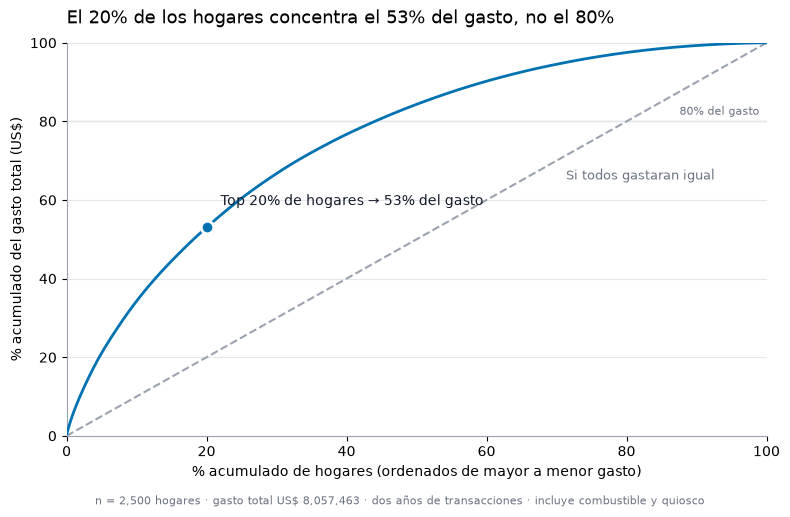

In [23]:
# =========================================================
# Gráfico 1 · Curva de concentración acumulada del gasto (tipo Pareto / Lorenz)
# =========================================================
import os

n_hogares = len(gasto_hh_total)
x = np.arange(1, n_hogares + 1) / n_hogares * 100      # % acumulado de hogares
y = acum_total.values * 100                            # % acumulado del gasto

fig, ax = plt.subplots(figsize=(8, 5))

# Línea de referencia: cómo se vería si todos los hogares gastaran lo mismo
ax.plot([0, 100], [0, 100], color="#9ca3af", lw=1.5, ls="--", zorder=1)
ax.text(
    82, 68, "Si todos gastaran igual",
    color="#6b7280", fontsize=9, ha="center", va="top",
)

# Curva observada
ax.plot(x, y, color="#0072B2", lw=2, zorder=3)

# Punto de referencia: el top 20%
n20 = int(round(0.20 * n_hogares))
y20 = acum_total.iloc[n20 - 1] * 100
ax.plot([20], [y20], "o", ms=9, color="#0072B2", mec="white", mew=2, zorder=4)
ax.annotate(
    f"Top 20% de hogares → {y20:.0f}% del gasto",
    xy=(20, y20), xytext=(10, 16), textcoords="offset points",
    fontsize=10, color="#111827",
)

# Referencia del 80/20 que NO se cumple
ax.axhline(80, color="#d1d5db", lw=1, zorder=0)
ax.text(99, 81, "80% del gasto", fontsize=8, color="#6b7280", ha="right", va="bottom")

ax.set_title(
    "El 20% de los hogares concentra el 53% del gasto, no el 80%",
    fontsize=13, pad=14, loc="left",
)
ax.set_xlabel("% acumulado de hogares (ordenados de mayor a menor gasto)")
ax.set_ylabel("% acumulado del gasto total (US$)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(axis="y", color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
for lado in ["left", "bottom"]:
    ax.spines[lado].set_color("#9ca3af")

fig.text(
    0.125, -0.02,
    f"n = {n_hogares:,} hogares · gasto total US$ {gasto_hh_total.sum():,.0f} "
    f"· dos años de transacciones · incluye combustible y quiosco",
    fontsize=8, color="#6b7280",
)

plt.tight_layout()

# Guardar para la presentación
os.makedirs("figuras", exist_ok=True)
fig.savefig("figuras/g1_concentracion_gasto.png", dpi=200, bbox_inches="tight")
plt.show()

**No de la forma que se suele asumir.** La curva se separa claramente de la diagonal —
hay concentración real — pero cruza el 80% del gasto recién cerca del 44% de los hogares,
muy lejos del 20% que predice la regla de Pareto. La minoría que importa son los 454
hogares (18.2%) que explican la mitad del gasto; por debajo de eso, la base de clientes
sigue aportando volumen que no se puede desatender.

In [24]:
# =========================================================
# Utilidad obligatoria: reconciliar filas y totales antes/después de cada operación
# (función de la sesión práctica 2, requerida por el enunciado)
# =========================================================
def reconciliar(antes, despues, metrica, etiqueta=""):
    """Compara filas y total de una metrica antes y despues de una operacion."""
    f0, f1 = len(antes), len(despues)
    m0, m1 = antes[metrica].sum(), despues[metrica].sum()
    ok = bool((f0 == f1) and np.isclose(m0, m1))
    print(f"{'OK' if ok else 'ALERTA'} {etiqueta}")
    print(f"   filas    : {f0:,} -> {f1:,}   ({f1 - f0:+,})")
    print(f"   {metrica}: {m0:,.2f} -> {m1:,.2f}   ({m1 - m0:+,.2f})")
    return ok

In [25]:
# =========================================================
# Análisis 2 · Mix de categorías: ranking por venta y por crecimiento
# Pregunta: ¿qué departamentos y categorías pesan más, y cuáles están creciendo?
# =========================================================

# ---------- 1. Definir el eje temporal (no hay fechas de calendario) ----------
# Los datos solo tienen DAY (1-711) y WEEK_NO (1-102): no hay meses ni año calendario.
# Antes de partir el período en dos, se verifica que las semanas de los extremos
# estén completas; una semana truncada subestimaría el período que la contiene.
tx_mix = transaction_data.loc[
    mask_retail, ["PRODUCT_ID", "WEEK_NO", "SALES_VALUE", "DAY"]
]

dias_por_semana = tx_mix.groupby("WEEK_NO")["DAY"].nunique()
incompletas = dias_por_semana[dias_por_semana < 7]

print("=== COMPLETITUD DE LAS SEMANAS ===")
print(f"Semanas presentes: {dias_por_semana.index.min()} a {dias_por_semana.index.max()}")
print(f"Semanas con menos de 7 días distintos: {len(incompletas)}")
if len(incompletas):
    print(incompletas.to_string())

semanas_completas = dias_por_semana[dias_por_semana == 7].index
W_MIN, W_MAX = int(semanas_completas.min()), int(semanas_completas.max())
CORTE = (W_MIN + W_MAX) // 2

print(
    f"\nSe usan solo semanas completas: {W_MIN} a {W_MAX}"
    f"  ({len(semanas_completas)} semanas)"
)
print(f"  Período 1 (base):  semanas {W_MIN}-{CORTE}   ({CORTE - W_MIN + 1} semanas)")
print(f"  Período 2 (reciente): semanas {CORTE + 1}-{W_MAX}   ({W_MAX - CORTE} semanas)")

tx_mix = tx_mix[tx_mix["WEEK_NO"].between(W_MIN, W_MAX)].copy()
tx_mix["PERIODO"] = np.where(tx_mix["WEEK_NO"] <= CORTE, "P1", "P2")

# ---------- 2. Llevar la venta al nivel de categoría ----------
venta_prod = (
    tx_mix.groupby(["PRODUCT_ID", "PERIODO"], as_index=False)["SALES_VALUE"].sum()
)
antes = venta_prod.copy()
venta_prod = venta_prod.merge(
    product[["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC"]],
    on="PRODUCT_ID",
    how="left",
    validate="m:1",
)
reconciliar(antes, venta_prod, "SALES_VALUE", "merge venta_prod <- product")

# ---------- 3. Ranking por VENTA ----------
por_depto_venta = (
    venta_prod.groupby("DEPARTMENT")["SALES_VALUE"].sum().sort_values(ascending=False)
)
total_venta = por_depto_venta.sum()

print("\n=== RANKING POR VENTA — DEPARTAMENTOS (top 12) ===")
for depto, v in por_depto_venta.head(12).items():
    print(f"  {depto:<18} US$ {v:>11,.0f}   {v / total_venta:>6.1%} del total")

cat = venta_prod.pivot_table(
    index="COMMODITY_DESC",
    columns="PERIODO",
    values="SALES_VALUE",
    aggfunc="sum",
    fill_value=0.0,
)
cat["TOTAL"] = cat["P1"] + cat["P2"]
cat["CRECIMIENTO"] = np.where(
    cat["P1"] > 0, (cat["P2"] - cat["P1"]) / cat["P1"], np.nan
)

print("\n=== RANKING POR VENTA — CATEGORÍAS (top 15) ===")
print(
    cat.sort_values("TOTAL", ascending=False)
    .head(15)[["P1", "P2", "TOTAL", "CRECIMIENTO"]]
    .to_string(
        formatters={
            "P1": "{:,.0f}".format,
            "P2": "{:,.0f}".format,
            "TOTAL": "{:,.0f}".format,
            "CRECIMIENTO": "{:+.1%}".format,
        }
    )
)

# ---------- 4. El error a evitar: crecimiento SIN filtro de volumen ----------
print("\n" + "=" * 70)
print("DEMOSTRACIÓN DEL SESGO — top 10 de crecimiento SIN filtro de volumen")
print("=" * 70)
print(
    cat[cat["P1"] > 0]
    .sort_values("CRECIMIENTO", ascending=False)
    .head(10)[["P1", "P2", "CRECIMIENTO"]]
    .to_string(
        formatters={
            "P1": "{:,.0f}".format,
            "P2": "{:,.0f}".format,
            "CRECIMIENTO": "{:+.1%}".format,
        }
    )
)

# ---------- 5. El ranking válido: crecimiento CON filtro declarado ----------
# Filtro de volumen mínimo DECLARADO: la categoría debe haber vendido al menos
# US$ 20,000 en el período base (P1). Con bases más pequeñas, el crecimiento
# porcentual mide ruido: unas pocas canastas mueven el indicador decenas de puntos.
UMBRAL_P1 = 20_000
elegibles_cat = cat[cat["P1"] >= UMBRAL_P1].copy()

print("\n" + "=" * 70)
print(f"RANKING VÁLIDO — crecimiento con filtro P1 >= US$ {UMBRAL_P1:,}")
print("=" * 70)
print(
    f"Categorías que pasan el filtro: {len(elegibles_cat)} de {len(cat)}   "
    f"(cubren {elegibles_cat['TOTAL'].sum() / cat['TOTAL'].sum():.1%} de la venta)"
)
print("\n-- Las 10 que MÁS crecen --")
print(
    elegibles_cat.sort_values("CRECIMIENTO", ascending=False)
    .head(10)[["P1", "P2", "TOTAL", "CRECIMIENTO"]]
    .to_string(
        formatters={
            "P1": "{:,.0f}".format,
            "P2": "{:,.0f}".format,
            "TOTAL": "{:,.0f}".format,
            "CRECIMIENTO": "{:+.1%}".format,
        }
    )
)
print("\n-- Las 10 que MÁS caen --")
print(
    elegibles_cat.sort_values("CRECIMIENTO")
    .head(10)[["P1", "P2", "TOTAL", "CRECIMIENTO"]]
    .to_string(
        formatters={
            "P1": "{:,.0f}".format,
            "P2": "{:,.0f}".format,
            "TOTAL": "{:,.0f}".format,
            "CRECIMIENTO": "{:+.1%}".format,
        }
    )
)

# ---------- 6. ¿Crece la cadena en su conjunto? ----------
p1_tot, p2_tot = cat["P1"].sum(), cat["P2"].sum()
print(f"\n=== LÍNEA BASE DE LA CADENA ===")
print(f"  Venta P1: US$ {p1_tot:,.0f}")
print(f"  Venta P2: US$ {p2_tot:,.0f}")
print(f"  Variación total: {(p2_tot - p1_tot) / p1_tot:+.1%}")
print("  (toda lectura de crecimiento por categoría debe compararse contra este número)")

=== COMPLETITUD DE LAS SEMANAS ===
Semanas presentes: 1 a 102
Semanas con menos de 7 días distintos: 2
WEEK_NO
1      5
102    6

Se usan solo semanas completas: 2 a 101  (100 semanas)
  Período 1 (base):  semanas 2-51   (50 semanas)
  Período 2 (reciente): semanas 52-101   (50 semanas)
OK merge venta_prod <- product
   filas    : 130,031 -> 130,031   (+0)
   SALES_VALUE: 7,322,488.74 -> 7,322,488.74   (+0.00)

=== RANKING POR VENTA — DEPARTAMENTOS (top 12) ===
  GROCERY            US$   4,054,057    55.4% del total
  DRUG GM            US$   1,045,254    14.3% del total
  PRODUCE            US$     552,251     7.5% del total
  MEAT               US$     544,237     7.4% del total
  MEAT-PCKGD         US$     408,641     5.6% del total
  DELI               US$     258,346     3.5% del total
  PASTRY             US$     120,742     1.6% del total
  NUTRITION          US$      96,474     1.3% del total
  SEAFOOD-PCKGD      US$      62,221     0.8% del total
  FLORAL             US$      

In [26]:
# =========================================================
# Análisis 2 (continuación) · ¿El crecimiento es real?
# El +24.7% de la cadena es sospechosamente alto para un retail maduro.
# Antes de atribuirlo al negocio hay que verificar que el panel sea comparable.
# =========================================================

panel = (
    transaction_data.loc[mask_retail, ["WEEK_NO", "household_key", "SALES_VALUE"]]
    .groupby("WEEK_NO")
    .agg(venta=("SALES_VALUE", "sum"), hogares=("household_key", "nunique"))
)
panel["venta_x_hogar"] = panel["venta"] / panel["hogares"]

print("=== HOGARES ACTIVOS POR SEMANA — ¿es el panel comparable? ===")
print("semana | hogares activos |     venta | venta por hogar")
for s in [2, 5, 10, 15, 16, 20, 25, 40, 51, 52, 70, 90, 101, 102]:
    if s in panel.index:
        r = panel.loc[s]
        print(f"{s:>6} | {r.hogares:>15,.0f} | {r.venta:>9,.0f} | {r.venta_x_hogar:>15.2f}")

primera_semana = (
    transaction_data.loc[mask_retail].groupby("household_key")["WEEK_NO"].min()
)
print(f"\nPrimera semana activa por hogar — mediana: {primera_semana.median():.0f}, "
      f"percentil 75: {primera_semana.quantile(0.75):.0f}, máximo: {primera_semana.max():.0f}")

nivel_estable = panel.loc[52:101, "hogares"].mean()
W_EST = int(panel[panel["hogares"] >= 0.9 * nivel_estable].index.min())
print(f"Hogares activos promedio en semanas 52-101: {nivel_estable:,.0f}")
print(f"Primera semana que alcanza el 90% de ese nivel: {W_EST}")

# Ventana de comparación DECLARADA: se descartan las semanas de incorporación
# del panel y se usa 20-101, con margen sobre la semana de estabilización.
W_INI, W_FIN = 20, 101
CORTE2 = (W_INI + W_FIN) // 2

a = panel.loc[W_INI:CORTE2]
b = panel.loc[CORTE2 + 1 : W_FIN]
crec_cadena_bruto = b["venta"].sum() / a["venta"].sum() - 1
crec_x_hogar = b["venta_x_hogar"].mean() / a["venta_x_hogar"].mean() - 1

print(f"\n=== CRECIMIENTO CORREGIDO — ventana estable {W_INI}-{W_FIN} ===")
print(f"  Corte: semanas {W_INI}-{CORTE2} vs {CORTE2 + 1}-{W_FIN}")
print(f"  Venta total:            {a['venta'].sum():>12,.0f} -> "
      f"{b['venta'].sum():>12,.0f}   {crec_cadena_bruto:+.1%}")
print(f"  Venta por hogar-semana: {a['venta_x_hogar'].mean():>12.2f} -> "
      f"{b['venta_x_hogar'].mean():>12.2f}   {crec_x_hogar:+.1%}")
print(f"  Hogares activos/semana: {a['hogares'].mean():>12,.0f} -> "
      f"{b['hogares'].mean():>12,.0f}   "
      f"{b['hogares'].mean() / a['hogares'].mean() - 1:+.1%}")
print(f"\n  Comparación con la ventana sin corregir (semanas 2-101): +24.7%")
print(f"  El exceso es rampa de incorporación del panel, no crecimiento del negocio.")

# ---------- Ranking de categorías, recalculado sobre la ventana estable ----------
tx_est = transaction_data.loc[
    mask_retail & transaction_data["WEEK_NO"].between(W_INI, W_FIN),
    ["PRODUCT_ID", "WEEK_NO", "SALES_VALUE"],
].copy()
tx_est["PERIODO"] = np.where(tx_est["WEEK_NO"] <= CORTE2, "P1", "P2")

v2 = tx_est.groupby(["PRODUCT_ID", "PERIODO"], as_index=False)["SALES_VALUE"].sum()
antes = v2.copy()
v2 = v2.merge(
    product[["PRODUCT_ID", "COMMODITY_DESC"]],
    on="PRODUCT_ID",
    how="left",
    validate="m:1",
)
reconciliar(antes, v2, "SALES_VALUE", "merge ventana estable <- product")

cat2 = v2.pivot_table(
    index="COMMODITY_DESC", columns="PERIODO", values="SALES_VALUE",
    aggfunc="sum", fill_value=0.0,
)
cat2["TOTAL"] = cat2["P1"] + cat2["P2"]
cat2["CRECIMIENTO"] = np.where(
    cat2["P1"] > 0, (cat2["P2"] - cat2["P1"]) / cat2["P1"], np.nan
)
# Crecimiento RELATIVO: puntos porcentuales por encima o debajo de la cadena.
# Una categoría que crece menos que la cadena está perdiendo participación.
cat2["VS_CADENA_PP"] = (cat2["CRECIMIENTO"] - crec_cadena_bruto) * 100

UMBRAL_P1 = 20_000
eleg2 = cat2[cat2["P1"] >= UMBRAL_P1].copy()

fmt = {
    "P1": "{:,.0f}".format, "P2": "{:,.0f}".format, "TOTAL": "{:,.0f}".format,
    "CRECIMIENTO": "{:+.1%}".format, "VS_CADENA_PP": "{:+.1f} pp".format,
}
cols = ["P1", "P2", "TOTAL", "CRECIMIENTO", "VS_CADENA_PP"]

print(f"\n=== CATEGORÍAS QUE GANAN PARTICIPACIÓN "
      f"(filtro P1 >= US$ {UMBRAL_P1:,}; {len(eleg2)} de {len(cat2)} categorías) ===")
print(eleg2.sort_values("VS_CADENA_PP", ascending=False).head(10)[cols].to_string(formatters=fmt))

print("\n=== CATEGORÍAS QUE PIERDEN PARTICIPACIÓN ===")
print(eleg2.sort_values("VS_CADENA_PP").head(10)[cols].to_string(formatters=fmt))

=== HOGARES ACTIVOS POR SEMANA — ¿es el panel comparable? ===
semana | hogares activos |     venta | venta por hogar
     2 |             175 |    10,804 |           61.74
     5 |             367 |    19,921 |           54.28
    10 |             695 |    40,872 |           58.81
    15 |           1,131 |    69,695 |           61.62
    16 |           1,285 |    74,793 |           58.20
    20 |           1,295 |    80,388 |           62.08
    25 |           1,318 |    80,504 |           61.08
    40 |           1,254 |    82,559 |           65.84
    51 |           1,266 |    77,924 |           61.55
    52 |           1,274 |    78,440 |           61.57
    70 |           1,278 |    76,042 |           59.50
    90 |           1,324 |    85,773 |           64.78
   101 |           1,238 |    76,922 |           62.13
   102 |           1,176 |    65,582 |           55.77

Primera semana activa por hogar — mediana: 11, percentil 75: 14, máximo: 97
Hogares activos promedio en semanas 

In [27]:
# Cohorte estable: hogares activos en AMBAS ventanas (A y B)
hogares_A = set(
    transaction_data.loc[
        mask_retail & transaction_data["WEEK_NO"].between(W_INI, CORTE2), "household_key"
    ].unique()
)
hogares_B = set(
    transaction_data.loc[
        mask_retail & transaction_data["WEEK_NO"].between(CORTE2 + 1, W_FIN), "household_key"
    ].unique()
)
hogares_ambas = hogares_A & hogares_B

print(f"Hogares activos en ventana A: {len(hogares_A):,}")
print(f"Hogares activos en ventana B: {len(hogares_B):,}")
print(f"Hogares activos en AMBAS (cohorte estable): {len(hogares_ambas):,}")
print(f"Solo en A (dejaron de comprar): {len(hogares_A - hogares_B):,}")
print(f"Solo en B (nuevos o reactivados): {len(hogares_B - hogares_A):,}")

# Gasto de la cohorte estable en cada ventana
gasto_A_cohorte = transaction_data.loc[
    mask_retail
    & transaction_data["WEEK_NO"].between(W_INI, CORTE2)
    & transaction_data["household_key"].isin(hogares_ambas),
    "SALES_VALUE",
].sum()

gasto_B_cohorte = transaction_data.loc[
    mask_retail
    & transaction_data["WEEK_NO"].between(CORTE2 + 1, W_FIN)
    & transaction_data["household_key"].isin(hogares_ambas),
    "SALES_VALUE",
].sum()

crecimiento_cohorte = (gasto_B_cohorte - gasto_A_cohorte) / gasto_A_cohorte

print(f"\n=== CRECIMIENTO DE LA COHORTE ESTABLE (mismos hogares en A y B) ===")
print(f"Gasto ventana A: US$ {gasto_A_cohorte:,.0f}")
print(f"Gasto ventana B: US$ {gasto_B_cohorte:,.0f}")
print(f"Crecimiento: {crecimiento_cohorte:+.1%}")
print(f"\nComparar contra el +4.7% del agregado poblacional (con entradas/salidas de hogares)")

Hogares activos en ventana A: 2,441
Hogares activos en ventana B: 2,461
Hogares activos en AMBAS (cohorte estable): 2,411
Solo en A (dejaron de comprar): 30
Solo en B (nuevos o reactivados): 50

=== CRECIMIENTO DE LA COHORTE ESTABLE (mismos hogares en A y B) ===
Gasto ventana A: US$ 3,191,074
Gasto ventana B: US$ 3,325,428
Crecimiento: +4.2%

Comparar contra el +4.7% del agregado poblacional (con entradas/salidas de hogares)


**Una vez corregido el crecimiento inflado del panel (+4.7% real, no +24.7%), ¿qué
categorías están ganando o perdiendo participación relativa dentro de ese crecimiento?**

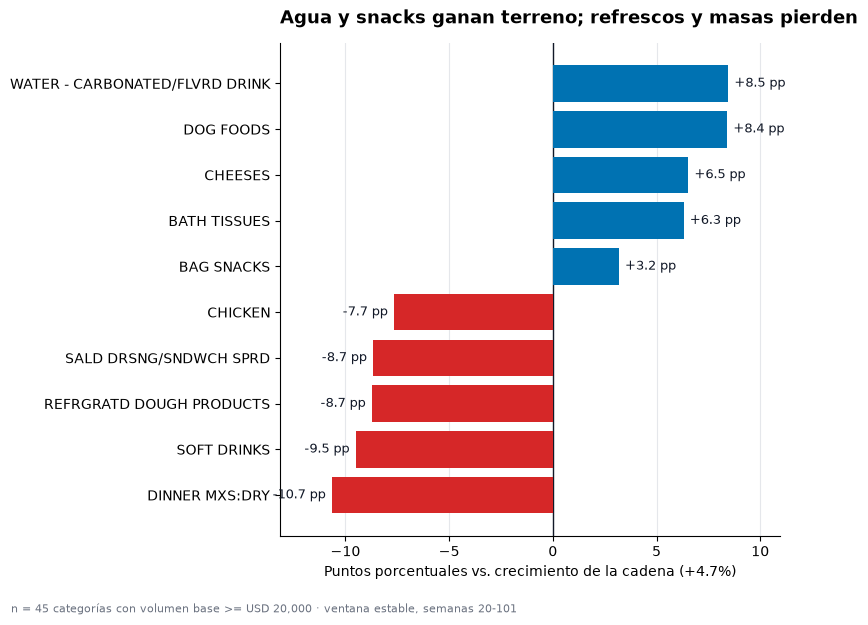

In [28]:
# =========================================================
# Gráfico Análisis 2 · Barras horizontales — ganadores y perdedores de participación
# =========================================================

top_gana = eleg2.sort_values("VS_CADENA_PP", ascending=False).head(5)
top_pierde = eleg2.sort_values("VS_CADENA_PP").head(5)

# Combinar para graficar juntas, ordenadas de mayor a menor VS_CADENA_PP
combinado = pd.concat([top_gana, top_pierde]).sort_values("VS_CADENA_PP")
colores = ["#d62728" if v < 0 else "#0072B2" for v in combinado["VS_CADENA_PP"]]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(combinado.index, combinado["VS_CADENA_PP"], color=colores, zorder=3)

# Etiquetas de valor — dentro del área del gráfico, nunca cortadas
for bar, val in zip(bars, combinado["VS_CADENA_PP"]):
    if val >= 0:
        x_pos = val + 0.3
        ha = "left"
    else:
        x_pos = val - 0.3
        ha = "right"
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.1f} pp",
        va="center",
        ha=ha,
        fontsize=9,
        color="#111827",
    )

# Margen extra en el eje X para que ninguna etiqueta quede cortada
ax.set_xlim(combinado["VS_CADENA_PP"].min() - 2.5, combinado["VS_CADENA_PP"].max() + 2.5)

ax.axvline(0, color="#111827", lw=1, zorder=2)
ax.set_xlabel("Puntos porcentuales vs. crecimiento de la cadena (+4.7%)")
ax.set_title(
    "Agua y snacks ganan terreno; refrescos y masas pierden",
    fontsize=13, pad=14, loc="left", fontweight="bold",
)
ax.set_ylabel("")

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.grid(axis="x", color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)

fig.text(
    0.02, -0.03,
    f"n = {len(eleg2)} categorías con volumen base >= USD {UMBRAL_P1:,} · "
    f"ventana estable, semanas {W_INI}-{W_FIN}",
    fontsize=8, color="#6b7280",
)

plt.tight_layout()

os.makedirs("figuras", exist_ok=True)
fig.savefig("figuras/g2_ganadores_perdedores.png", dpi=200, bbox_inches="tight")
plt.show()

### Análisis 2 — Mix de categorías: el crecimiento aparente es un artefacto del panel

**El ranking por venta está muy concentrado:** `GROCERY` representa el 55.4% de la venta
y `DRUG GM` el 14.3%; los dos departamentos juntos son casi el 70% del negocio. Por
categoría, `SOFT DRINKS` (US\$ 324,172) y `BEEF` (US\$ 309,673) encabezan la lista.

**El crecimiento, en cambio, no se puede leer directamente.** Una primera medición
partiendo las semanas completas por la mitad (2-51 vs 52-101) arroja un crecimiento
de la cadena de **+24.7%**, una cifra implausible para un retail maduro. La verificación
del panel explica por qué: **el número de hogares activos no es constante.** En la
semana 2 hay 175 hogares activos; en la semana 15 hay 1,131; desde la semana 16 el panel
se estabiliza en ~1,308. La mediana de la primera semana activa de un hogar es la
semana 11. El período base no es un año de operación, es un panel en construcción.

**Ventana de comparación declarada: semanas 20-101**, con margen sobre la semana 16 de
estabilización. Medido así, el crecimiento real es **+4.7% en venta total y +2.2% en
venta por hogar-semana** — no +24.7%. En consecuencia, toda lectura temporal que incluya
las primeras quince semanas está inflada, y el crecimiento por categoría debe expresarse
en puntos porcentuales **relativos al +4.7% de la cadena**, no en términos absolutos:
una categoría que crece +3% está perdiendo participación.

**Filtro de volumen mínimo declarado: US\$ 20,000 de venta en el período base**, que deja
45 de 307 categorías y cubre el 55.5% de la venta. La necesidad del filtro se demuestra
en la celda anterior: sin él, el top-10 de crecimiento lo encabeza `NEW AGE` con +430.1%
sobre una base de **US\$ 274** — ruido de unas pocas canastas, no una tendencia.

**Ganan participación:** `WATER - CARBONATED/FLVRD DRINK` (+8.5 pp sobre la cadena),
`DOG FOODS` (+8.4 pp), `CHEESES` (+6.5 pp), `BATH TISSUES` (+6.3 pp).
**Pierden participación:** `DINNER MXS:DRY` (−10.7 pp), `SOFT DRINKS` (−9.5 pp),
`REFRGRATD DOUGH PRODUCTS` (−8.7 pp), `CHICKEN` (−7.7 pp).

*(Ver celdas de código del Análisis 2)*

In [29]:
# =========================================================
# Análisis 3 · El costo del descuento
# Pregunta: ¿cuánto del valor vendido se fue en descuento, y sobre qué productos?
# =========================================================

COLS_DESC = ["RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"]

# ---------- 1. Verificación de signos ANTES de sumar nada ----------
print("=== SIGNO DE LAS COLUMNAS DE DESCUENTO ===")
for c in COLS_DESC:
    s = transaction_data[c]
    print(
        f"{c:>18}:  min {s.min():>9.2f}   max {s.max():>7.2f}   "
        f"negativos {(s < 0).mean():>6.2%}   ceros {(s == 0).mean():>6.2%}   "
        f"positivos {(s > 0).mean():>6.2%}"
    )

# ---------- 2. Definiciones explícitas ----------
# SALES_VALUE  = precio PAGADO por el cliente (ya neto de descuentos).
# Los descuentos vienen con signo NEGATIVO, así que se invierten para tratarlos
# como un costo positivo.
# precio de LISTA = precio pagado + descuento total otorgado.
#
# Quién absorbe cada descuento (User Guide de dunnhumby):
#   RETAIL_DISC       -> lo paga el RETAILER (programa de lealtad)
#   COUPON_MATCH_DISC -> lo paga el RETAILER (igualación del cupón del fabricante)
#   COUPON_DISC       -> lo paga el FABRICANTE
# Sumar los tres como "nuestro costo" sobreestima el gasto del retailer.

pagado = transaction_data["SALES_VALUE"].sum()
desc = {c: -transaction_data[c].sum() for c in COLS_DESC}
desc_total = sum(desc.values())
costo_retailer = desc["RETAIL_DISC"] + desc["COUPON_MATCH_DISC"]
costo_fabricante = desc["COUPON_DISC"]
lista = pagado + desc_total

print("\n=== EL COSTO DEL DESCUENTO, EN TOTAL ===")
print(f"  Precio de lista (pagado + descuentos):  US$ {lista:>12,.0f}")
print(f"  Precio pagado por el cliente:           US$ {pagado:>12,.0f}")
print(f"  Descuento total otorgado:               US$ {desc_total:>12,.0f}"
      f"   ({desc_total / lista:.1%} del precio de lista)")
print()
for c in COLS_DESC:
    print(f"    {c:>18}: US$ {desc[c]:>11,.0f}   "
          f"({desc[c] / desc_total:>5.1%} del descuento)")
print()
print(f"  Costo que absorbe el RETAILER:          US$ {costo_retailer:>12,.0f}"
      f"   ({costo_retailer / lista:.1%} del precio de lista)")
print(f"  Costo que absorbe el FABRICANTE:        US$ {costo_fabricante:>12,.0f}"
      f"   ({costo_fabricante / lista:.1%} del precio de lista)")

# ---------- 3. ¿Sobre qué productos se aplicó? ----------
por_producto = (
    transaction_data.groupby("PRODUCT_ID")[["SALES_VALUE"] + COLS_DESC]
    .sum()
    .reset_index()
)
antes = por_producto.copy()
por_producto = por_producto.merge(
    product[["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC", "BRAND"]],
    on="PRODUCT_ID",
    how="left",
    validate="m:1",
)
print()
reconciliar(antes, por_producto, "SALES_VALUE", "merge por_producto <- product")

for c in COLS_DESC:
    por_producto[c] = -por_producto[c]
por_producto["DESC_TOTAL"] = por_producto[COLS_DESC].sum(axis=1)
por_producto["DESC_RETAILER"] = (
    por_producto["RETAIL_DISC"] + por_producto["COUPON_MATCH_DISC"]
)
por_producto["LISTA"] = por_producto["SALES_VALUE"] + por_producto["DESC_TOTAL"]

por_depto = (
    por_producto.groupby("DEPARTMENT")[
        ["LISTA", "SALES_VALUE", "DESC_TOTAL", "DESC_RETAILER"]
    ]
    .sum()
    .sort_values("DESC_RETAILER", ascending=False)
)
por_depto["TASA_DESC"] = por_depto["DESC_TOTAL"] / por_depto["LISTA"]
por_depto["TASA_RETAILER"] = por_depto["DESC_RETAILER"] / por_depto["LISTA"]
por_depto["PCT_DEL_DESC"] = por_depto["DESC_RETAILER"] / costo_retailer

print("\n=== DÓNDE SE VA EL DESCUENTO QUE PAGA EL RETAILER (top 12 departamentos) ===")
print(
    por_depto.head(12)[
        ["LISTA", "DESC_RETAILER", "TASA_RETAILER", "PCT_DEL_DESC"]
    ].to_string(
        formatters={
            "LISTA": "{:,.0f}".format,
            "DESC_RETAILER": "{:,.0f}".format,
            "TASA_RETAILER": "{:.1%}".format,
            "PCT_DEL_DESC": "{:.1%}".format,
        }
    )
)

# Filtro de volumen mínimo DECLARADO: para comparar tasas de descuento entre
# categorías se exige al menos 0.5% del precio de lista total. Sin este filtro,
# una categoría marginal con un descuento puntual aparecería como la más
# descontada de la cadena.
UMBRAL = 0.005 * lista
por_commodity = (
    por_producto.groupby("COMMODITY_DESC")[["LISTA", "DESC_TOTAL", "DESC_RETAILER"]]
    .sum()
)
elegibles = por_commodity[por_commodity["LISTA"] >= UMBRAL].copy()
elegibles["TASA_RETAILER"] = elegibles["DESC_RETAILER"] / elegibles["LISTA"]

print(
    f"\n=== TASA DE DESCUENTO POR CATEGORÍA "
    f"(filtro: >= US$ {UMBRAL:,.0f} de precio de lista = 0.5% del total) ==="
)
print(f"Categorías que pasan el filtro: {len(elegibles)} de {len(por_commodity)}")
print("\n-- Las 10 MÁS descontadas --")
print(
    elegibles.sort_values("TASA_RETAILER", ascending=False)
    .head(10)[["LISTA", "DESC_RETAILER", "TASA_RETAILER"]]
    .to_string(
        formatters={
            "LISTA": "{:,.0f}".format,
            "DESC_RETAILER": "{:,.0f}".format,
            "TASA_RETAILER": "{:.1%}".format,
        }
    )
)
print("\n-- Las 10 MENOS descontadas --")
print(
    elegibles.sort_values("TASA_RETAILER")
    .head(10)[["LISTA", "DESC_RETAILER", "TASA_RETAILER"]]
    .to_string(
        formatters={
            "LISTA": "{:,.0f}".format,
            "DESC_RETAILER": "{:,.0f}".format,
            "TASA_RETAILER": "{:.1%}".format,
        }
    )
)

# ---------- 4. Marca propia vs nacional ----------
por_marca = (
    por_producto.groupby("BRAND")[["LISTA", "DESC_TOTAL", "DESC_RETAILER"]].sum()
)
por_marca["TASA_RETAILER"] = por_marca["DESC_RETAILER"] / por_marca["LISTA"]
print("\n=== DESCUENTO POR TIPO DE MARCA ===")
print(
    por_marca.to_string(
        formatters={
            "LISTA": "{:,.0f}".format,
            "DESC_TOTAL": "{:,.0f}".format,
            "DESC_RETAILER": "{:,.0f}".format,
            "TASA_RETAILER": "{:.1%}".format,
        }
    )
)

=== SIGNO DE LAS COLUMNAS DE DESCUENTO ===
       RETAIL_DISC:  min   -180.00   max    3.99   negativos 50.20%   ceros 49.80%   positivos  0.00%
       COUPON_DISC:  min    -55.93   max    0.00   negativos  1.40%   ceros 98.60%   positivos  0.00%
 COUPON_MATCH_DISC:  min     -7.70   max    0.00   negativos  0.67%   ceros 99.33%   positivos  0.00%

=== EL COSTO DEL DESCUENTO, EN TOTAL ===
  Precio de lista (pagado + descuentos):  US$    9,505,985
  Precio pagado por el cliente:           US$    8,057,463
  Descuento total otorgado:               US$    1,448,522   (15.2% del precio de lista)

           RETAIL_DISC: US$   1,398,335   (96.5% del descuento)
           COUPON_DISC: US$      42,612   ( 2.9% del descuento)
     COUPON_MATCH_DISC: US$       7,576   ( 0.5% del descuento)

  Costo que absorbe el RETAILER:          US$    1,405,911   (14.8% del precio de lista)
  Costo que absorbe el FABRICANTE:        US$       42,612   (0.4% del precio de lista)

OK merge por_producto <- produ

In [30]:
huerfanos = por_producto[por_producto["DEPARTMENT"].isnull()]
print(f"Productos sin match en el catálogo: {len(huerfanos):,}")
print(f"SALES_VALUE de esos productos: US$ {huerfanos['SALES_VALUE'].sum():,.0f}")

# Verificación de completitud: ¿el desglose por departamento suma lo mismo que el total?
print(f"\nSuma de SALES_VALUE en por_depto: US$ {por_depto['SALES_VALUE'].sum():,.0f}" if "SALES_VALUE" in por_depto.columns else "")
print(f"Total real de SALES_VALUE: US$ {pagado:,.0f}")

Productos sin match en el catálogo: 0
SALES_VALUE de esos productos: US$ 0

Suma de SALES_VALUE en por_depto: US$ 8,057,463
Total real de SALES_VALUE: US$ 8,057,463


**¿La tasa de descuento se aplica de forma consistente sin importar cuánto vende un
producto, o es más errática en los productos de baja rotación?**

Total productos detectados con 0 < SALES_VALUE < $0.01: 1

Primeras filas con valores diminutos (formato exponencial y decimal):
          BRAND  SALES_VALUE   DESC_TOTAL        LISTA    TASA_DESC
36844  National 8.881784e-16 0.000000e+00 8.881784e-16 0.000000e+00

De ellos, con magnitud < 1e-9 (típico artefacto de suma IEEE 754): 1

Resumen de TASA_DESC en este grupo:
count    1.0
mean     0.0
std      NaN
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: TASA_DESC, dtype: float64

=== DISPERSIÓN DE LA TASA DE DESCUENTO POR DECIL DE VOLUMEN ===
            VENTA_MIN  VENTA_MAX  N_PRODUCTOS TASA_MEDIA TASA_STD
DECIL_VENTA                                                      
1                0.01       1.88         9273      15.1%    20.8%
2                1.88       2.99        10444      10.3%    16.3%
3                3.00       4.49         8161       9.6%    15.6%
4                4.50       6.98         8984       8.6%    14.3%
5                6.99      10.9

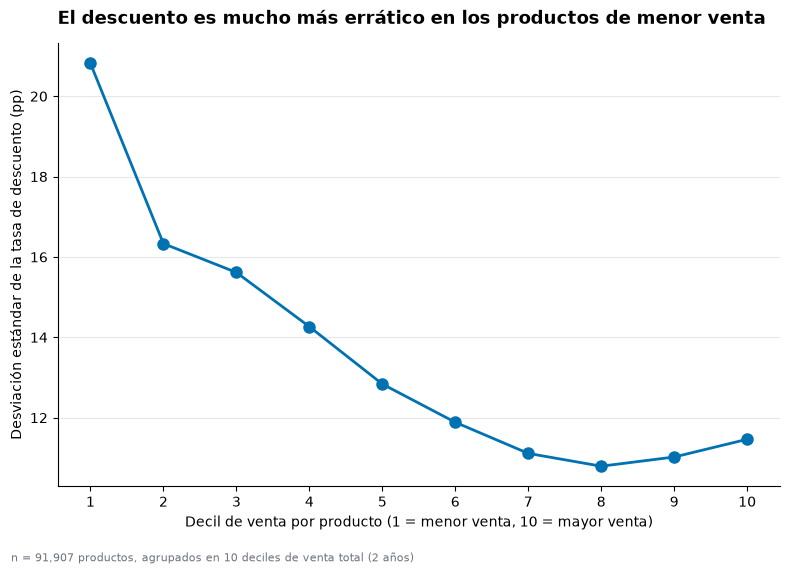

In [31]:
# =========================================================
# Gráfico Análisis 3 · Dispersión del descuento por decil de volumen
# =========================================================

# ---------- Preparación de datos a nivel de producto individual ----------
scatter_data = por_producto[por_producto["LISTA"] > 0].copy()
scatter_data["TASA_DESC"] = scatter_data["DESC_TOTAL"] / scatter_data["LISTA"]
scatter_data = scatter_data[scatter_data["SALES_VALUE"] > 0]

# Inspección: valores residuales / casi cero en SALES_VALUE
residuos = scatter_data[
    (scatter_data["SALES_VALUE"] > 0) & (scatter_data["SALES_VALUE"] < 0.01)
][["BRAND", "SALES_VALUE", "DESC_TOTAL", "LISTA", "TASA_DESC"]].copy()

print(f"Total productos detectados con 0 < SALES_VALUE < $0.01: {len(residuos):,}")

if not residuos.empty:
    print("\nPrimeras filas con valores diminutos (formato exponencial y decimal):")
    pd.set_option('display.float_format', lambda x: f"{x:.6e}")
    print(residuos.head(10))
    pd.reset_option('display.float_format')

    residuos_float = residuos[residuos["SALES_VALUE"] < 1e-9]
    print(f"\nDe ellos, con magnitud < 1e-9 (típico artefacto de suma IEEE 754): {len(residuos_float):,}")

    print("\nResumen de TASA_DESC en este grupo:")
    print(residuos["TASA_DESC"].describe())

# Filtro: excluir residuos de punto flotante antes de graficar
scatter_data = scatter_data[scatter_data["SALES_VALUE"] >= 0.01]

# ---------- pd.qcut divide en grupos con IGUAL CANTIDAD de productos ----------
# (deciles reales), a diferencia de pd.cut que divide el RANGO de valores en
# partes iguales (lo cual, con una distribución tan sesgada como esta, dejaría
# casi todos los productos en un solo bin).
scatter_data["DECIL_VENTA"] = pd.qcut(
    scatter_data["SALES_VALUE"], q=10, labels=False, duplicates="drop"
) + 1  # +1 para que los deciles vayan de 1 a 10, no de 0 a 9

resumen_decil = scatter_data.groupby("DECIL_VENTA").agg(
    VENTA_MIN=("SALES_VALUE", "min"),
    VENTA_MAX=("SALES_VALUE", "max"),
    N_PRODUCTOS=("SALES_VALUE", "size"),
    TASA_MEDIA=("TASA_DESC", "mean"),
    TASA_STD=("TASA_DESC", "std"),
)

print("\n=== DISPERSIÓN DE LA TASA DE DESCUENTO POR DECIL DE VOLUMEN ===")
print(resumen_decil.to_string(
    formatters={
        "VENTA_MIN": "{:,.2f}".format,
        "VENTA_MAX": "{:,.2f}".format,
        "TASA_MEDIA": "{:.1%}".format,
        "TASA_STD": "{:.1%}".format,
    }
))

# ---------- Gráfico ----------
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    resumen_decil.index, resumen_decil["TASA_STD"] * 100,
    marker="o", ms=8, color="#0072B2", lw=2, zorder=3,
)

ax.set_xlabel("Decil de venta por producto (1 = menor venta, 10 = mayor venta)")
ax.set_ylabel("Desviación estándar de la tasa de descuento (pp)")
ax.set_xticks(range(1, 11))
ax.set_title(
    "El descuento es mucho más errático en los productos de menor venta",
    fontsize=13, pad=14, loc="left", fontweight="bold",
)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.grid(axis="y", color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)

fig.text(
    0.02, -0.03,
    f"n = {len(scatter_data):,} productos, agrupados en 10 deciles de venta total (2 años)",
    fontsize=8, color="#6b7280",
)

plt.tight_layout()

os.makedirs("figuras", exist_ok=True)
fig.savefig("figuras/g3_dispersion_por_decil.png", dpi=200, bbox_inches="tight")
plt.show()

### Análisis 3 — El costo del descuento: casi todo es góndola, casi nada es cupón

**El descuento total otorgado fue de USD 1,448,522 sobre un precio de lista de
USD 9,505,985 — el 15.2%.** Definiciones usadas: `SALES_VALUE` es el precio *pagado*
por el cliente; el precio de *lista* se reconstruye como pagado + descuento, invirtiendo
el signo negativo con que vienen las tres columnas de descuento.

**La composición importa más que el total: `RETAIL_DISC` representa el 96.5% del
descuento otorgado, y los cupones (fabricante + igualación) solo el 3.4% combinado.**
Separando por quién absorbe el costo — el retailer paga `RETAIL_DISC` y
`COUPON_MATCH_DISC`; el fabricante paga `COUPON_DISC` — el retailer asume
USD 1,405,911 (14.8% del precio de lista) contra USD 42,612 del fabricante (0.4%).
En consecuencia, la Palanca C no es una elección entre dos mecánicas de tamaño
comparable: el descuento en góndola ya moviliza 33 veces más dinero que los cupones
dirigidos, y la pregunta relevante es si ese 14.8% está comprando incrementalidad.

**Concentración del descuento:** `GROCERY` absorbe el 58.6% del descuento del retailer
por volumen, pero las tasas más altas están en proteína fresca y perecederos —
`CHICKEN` 38.8%, `HOT DOGS` 34.5%, `ICE CREAM/MILK/SHERBTS` 32.0%, `PORK` 29.5%,
`BACON` 27.0% — patrón consistente con una estrategia de *loss leader* para generar
tráfico, no con descuento defensivo disperso.

**Filtro de volumen declarado:** para comparar tasas entre categorías se exigió un
mínimo de USD 47,530 de precio de lista (0.5% del total), lo que deja 57 de 308
categorías. Sin ese filtro, una categoría marginal con una promoción puntual aparecería
como la más descontada de la cadena.

**Ruido en el long tail del catálogo:** a nivel de producto individual, la dispersión
de la tasa de descuento (medida como desviación estándar) cae de 20.8% en el decil de
menor venta a un mínimo de 10.7% en el decil 8, para repuntar levemente en los deciles
9-10. Los productos de baja rotación (mediana de venta: USD 10.89 en 2 años) reciben
descuentos mucho más erráticos que los de alta rotación, probablemente por eventos
puntuales (liquidaciones, descontinuación) más que por una política de precios
sistemática. Esto refuerza la necesidad del filtro de volumen mínimo: sin él, el ruido
de estos productos marginales domina cualquier ranking de tasas por categoría.

**Advertencia de interpretación:** las categorías con tasa cercana a cero son
`CIGARETTES` (0.0%), `BEERS/ALES` (0.1%) y `DOMESTIC WINE` (0.2%). Esto **no** debe
leerse como espacio para descontar: la promoción de alcohol y tabaco está legalmente
restringida en gran parte de los estados de EE.UU. Se excluyen explícitamente de
cualquier recomendación de mecánica.

**Marca propia vs nacional:** la tasa de descuento del retailer es 15.4% en marca
nacional y 13.2% en marca propia — diferencia demasiado pequeña para sostener una
recomendación.

*(Ver celdas de código del Análisis 3)*

In [32]:
# =========================================================
# Análisis 2 × 3 · ¿El descuento está comprando crecimiento?
# Cruce: tasa de descuento por categoría vs. ganancia de participación,
#        ambos medidos sobre la misma ventana estable (semanas 20-101).
# =========================================================

tx_cruce = transaction_data.loc[
    mask_retail & transaction_data["WEEK_NO"].between(W_INI, W_FIN),
    ["PRODUCT_ID", "WEEK_NO", "SALES_VALUE", "RETAIL_DISC", "COUPON_MATCH_DISC"],
].copy()
tx_cruce["PERIODO"] = np.where(tx_cruce["WEEK_NO"] <= CORTE2, "P1", "P2")
tx_cruce["DESC_RET"] = -(tx_cruce["RETAIL_DISC"] + tx_cruce["COUPON_MATCH_DISC"])

antes = tx_cruce.copy()
tx_cruce = tx_cruce.merge(
    product[["PRODUCT_ID", "COMMODITY_DESC"]],
    on="PRODUCT_ID", how="left", validate="m:1",
)
reconciliar(antes, tx_cruce, "SALES_VALUE", "merge cruce <- product")

resumen = tx_cruce.groupby("COMMODITY_DESC").agg(
    VENTA=("SALES_VALUE", "sum"), DESC_RET=("DESC_RET", "sum")
)
resumen["LISTA"] = resumen["VENTA"] + resumen["DESC_RET"]
resumen["TASA_DESC"] = resumen["DESC_RET"] / resumen["LISTA"]
resumen = resumen.join(cat2[["P1", "P2", "CRECIMIENTO", "VS_CADENA_PP"]])

cruce = resumen[resumen["P1"] >= UMBRAL_P1].copy()
corr = cruce["TASA_DESC"].corr(cruce["VS_CADENA_PP"])

print("=== ¿EL DESCUENTO COMPRA CRECIMIENTO? ===")
print(f"Categorías analizadas: {len(cruce)} (filtro P1 >= US$ {UMBRAL_P1:,})")
print(f"Correlación entre tasa de descuento y ganancia de participación: {corr:+.3f}")
print("  (un valor negativo significa que las categorías más descontadas son las que")
print("   pierden participación — el descuento NO está asociado a ganar terreno)")

q_alto = cruce["TASA_DESC"].quantile(0.75)
q_bajo = cruce["TASA_DESC"].quantile(0.25)
alto = cruce[cruce["TASA_DESC"] >= q_alto]
bajo = cruce[cruce["TASA_DESC"] <= q_bajo]

print(f"\n=== COMPARACIÓN POR CUARTILES DE TASA DE DESCUENTO ===")
print(f"  Cuartil MÁS descontado  (tasa >= {q_alto:.1%}, n={len(alto)}):")
print(f"     participación media {alto['VS_CADENA_PP'].mean():+.1f} pp"
      f"   |   descuento US$ {alto['DESC_RET'].sum():,.0f}")
print(f"  Cuartil MENOS descontado (tasa <= {q_bajo:.1%}, n={len(bajo)}):")
print(f"     participación media {bajo['VS_CADENA_PP'].mean():+.1f} pp"
      f"   |   descuento US$ {bajo['DESC_RET'].sum():,.0f}")
print(f"\n  Razón de gasto: el cuartil que pierde participación recibe "
      f"{alto['DESC_RET'].sum() / bajo['DESC_RET'].sum():.1f}x más descuento.")

fuga = cruce[(cruce["VS_CADENA_PP"] < 0) & (cruce["TASA_DESC"] >= q_alto)].sort_values(
    "DESC_RET", ascending=False
)
fmt2 = {
    "VENTA": "{:,.0f}".format, "DESC_RET": "{:,.0f}".format,
    "TASA_DESC": "{:.1%}".format, "VS_CADENA_PP": "{:+.1f} pp".format,
}
print("\n=== CATEGORÍAS MUY DESCONTADAS QUE ADEMÁS PIERDEN PARTICIPACIÓN ===")
print(fuga[["VENTA", "DESC_RET", "TASA_DESC", "VS_CADENA_PP"]].to_string(formatters=fmt2))
print(f"\n  Descuento comprometido en ese grupo: US$ {fuga['DESC_RET'].sum():,.0f}")

print("\n=== EL CASO MÁS CLARO: REFRESCOS vs AGUA ===")
par = [c for c in ["SOFT DRINKS", "WATER - CARBONATED/FLVRD DRINK"] if c in resumen.index]
print(
    resumen.loc[par, ["VENTA", "DESC_RET", "TASA_DESC", "CRECIMIENTO", "VS_CADENA_PP"]]
    .to_string(formatters={**fmt2, "CRECIMIENTO": "{:+.1%}".format})
)
print("\n  Se subsidia con el doble de tasa la categoría que cae, frente a la que crece.")

OK merge cruce <- product
   filas    : 2,271,171 -> 2,271,171   (+0)
   SALES_VALUE: 6,543,986.84 -> 6,543,986.84   (+0.00)
=== ¿EL DESCUENTO COMPRA CRECIMIENTO? ===
Categorías analizadas: 45 (filtro P1 >= US$ 20,000)
Correlación entre tasa de descuento y ganancia de participación: -0.383
  (un valor negativo significa que las categorías más descontadas son las que
   pierden participación — el descuento NO está asociado a ganar terreno)

=== COMPARACIÓN POR CUARTILES DE TASA DE DESCUENTO ===
  Cuartil MÁS descontado  (tasa >= 20.5%, n=12):
     participación media -3.5 pp   |   descuento US$ 413,627
  Cuartil MENOS descontado (tasa <= 12.3%, n=12):
     participación media +1.5 pp   |   descuento US$ 64,920

  Razón de gasto: el cuartil que pierde participación recibe 6.4x más descuento.

=== CATEGORÍAS MUY DESCONTADAS QUE ADEMÁS PIERDEN PARTICIPACIÓN ===
                               VENTA DESC_RET TASA_DESC VS_CADENA_PP
COMMODITY_DESC                                               

**¿Las categorías más descontadas son las que más están ganando participación, o
sucede lo contrario?**

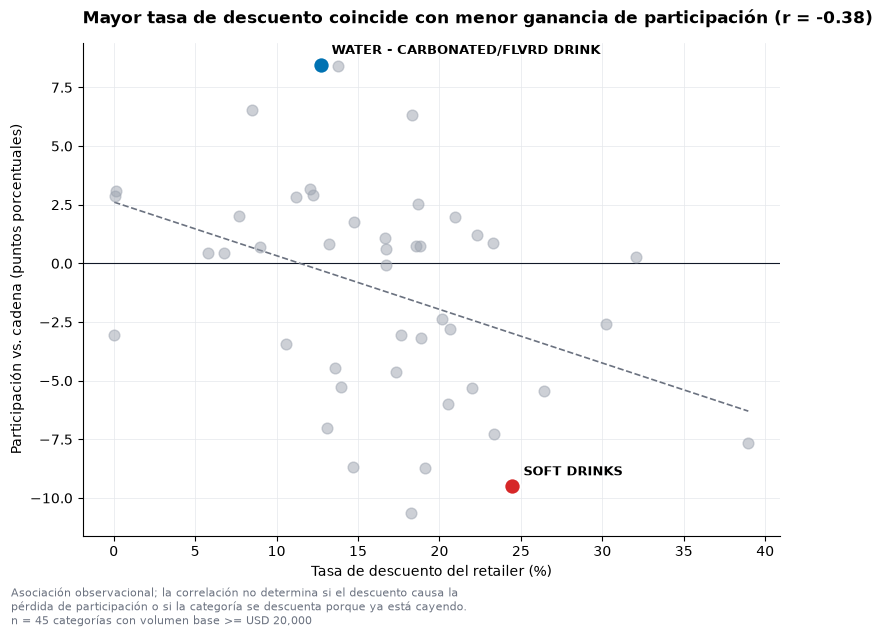

In [33]:
# =========================================================
# Gráfico Análisis 2×3 · Scatter — tasa de descuento vs. participación
# =========================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Puntos base: todas las categorías, en gris tenue (atenuación)
destacar = ["SOFT DRINKS", "WATER - CARBONATED/FLVRD DRINK"]
resto = cruce[~cruce.index.isin(destacar)]
foco = cruce[cruce.index.isin(destacar)]

ax.scatter(
    resto["TASA_DESC"] * 100, resto["VS_CADENA_PP"],
    s=60, alpha=0.5, color="#9ca3af", zorder=3, label="Otras categorías",
)

# Línea de tendencia (neutral, punteada, fina)
from numpy.polynomial import polynomial as P
coefs = np.polyfit(cruce["TASA_DESC"] * 100, cruce["VS_CADENA_PP"], 1)
x_linea = np.linspace(cruce["TASA_DESC"].min() * 100, cruce["TASA_DESC"].max() * 100, 50)
y_linea = coefs[0] * x_linea + coefs[1]
ax.plot(x_linea, y_linea, ls="--", lw=1.2, color="#6b7280", zorder=2)

# Puntos destacados: refrescos y agua (foco)
colores_foco = {"SOFT DRINKS": "#d62728", "WATER - CARBONATED/FLVRD DRINK": "#0072B2"}
for cat in destacar:
    if cat in foco.index:
        row = foco.loc[cat]
        ax.scatter(
            row["TASA_DESC"] * 100, row["VS_CADENA_PP"],
            s=140, color=colores_foco[cat], zorder=5,
            edgecolor="white", linewidth=1.5,
        )
        ax.annotate(
            cat, xy=(row["TASA_DESC"] * 100, row["VS_CADENA_PP"]),
            xytext=(8, 8), textcoords="offset points", fontsize=9, fontweight="bold",
        )

ax.axhline(0, color="#111827", lw=0.8, zorder=1)
ax.set_xlabel("Tasa de descuento del retailer (%)")
ax.set_ylabel("Participación vs. cadena (puntos porcentuales)")
ax.set_title(
    f"Mayor tasa de descuento coincide con menor ganancia de participación (r = {corr:.2f})",
    fontsize=12.5, pad=14, loc="left", fontweight="bold",
)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.grid(True, color="#e5e7eb", lw=0.5)
ax.set_axisbelow(True)

fig.text(
    0.02, -0.05,
    "Asociación observacional; la correlación no determina si el descuento causa la\n"
    "pérdida de participación o si la categoría se descuenta porque ya está cayendo.\n"
    f"n = {len(cruce)} categorías con volumen base >= USD {UMBRAL_P1:,}",
    fontsize=8, color="#6b7280",
)

plt.tight_layout()

os.makedirs("figuras", exist_ok=True)
fig.savefig("figuras/g23_scatter_descuento_participacion.png", dpi=200, bbox_inches="tight")
plt.show()

### Análisis 2 × 3 — El descuento no está comprando crecimiento

Cruzando ambos análisis sobre la misma ventana estable (semanas 20-101), **la correlación
entre tasa de descuento y ganancia de participación es −0.383**: las categorías más
descontadas son las que pierden terreno.

El contraste por cuartiles es el dato central del proyecto:

| Cuartil | Tasa de descuento | Descuento del retailer | Participación |
|---|---|---|---|
| Más descontado (n=12) | ≥ 20.5% | USD 413,627 | **−3.5 pp** |
| Menos descontado (n=12) | ≤ 12.3% | USD 64,920 | **+1.5 pp** |

**El cuartil que pierde participación recibe 6.4 veces más descuento que el que la gana.**
Ocho categorías que simultáneamente están muy descontadas y pierden participación
concentran **USD 286,822** de descuento — una quinta parte de todo el gasto promocional
que absorbe el retailer.

El caso más nítido es la sustitución de refrescos por agua:

| Categoría | Venta | Descuento | Tasa | vs. cadena |
|---|---|---|---|---|
| `SOFT DRINKS` | USD 285,859 | USD 92,647 | 24.5% | −9.5 pp |
| `WATER - CARBONATED/FLVRD DRINK` | USD 55,001 | USD 7,998 | 12.7% | +8.5 pp |

Se subsidia con el doble de tasa la categoría que cae frente a la que crece, y `SOFT
DRINKS` es a la vez la categoría con mayor venta y mayor descuento absoluto de la cadena.

**Riesgo principal de esta lectura — causalidad inversa.** Es igualmente consistente con
los datos que estas categorías se descuenten *porque* están cayendo: descuento defensivo
para retener volumen en un segmento en declive estructural. Con datos observacionales y
sin variación exógena en la política de precios, ambas explicaciones son indistinguibles.
Lo que sí es verificable es la asignación: el presupuesto promocional está concentrado
en las categorías que pierden participación, y eso es una decisión revisable
independientemente de la dirección de la causalidad.

*(Ver celda de código del Análisis 2 × 3)*

In [34]:
# =========================================================
# Análisis 4 · Campañas: ¿compraron más los hogares con campaña,
# y ya compraban más ANTES de la campaña?
# =========================================================

# 1. Resolver el nombre exacto de la columna de hogar
col_hogar_camp = 'household_key' if 'household_key' in campaign_table.columns else 'HOUSEHOLD_KEY'
col_hogar_tx = 'household_key' if 'household_key' in transaction_data.columns else 'HOUSEHOLD_KEY'

# 2. Extraer el día exacto donde arranca la ventana estable (Semana 20) según los datos reales
dia_inicio_estable = transaction_data.loc[transaction_data['WEEK_NO'] == 20, 'DAY'].min()
dia_corte_mitad = transaction_data.loc[transaction_data['WEEK_NO'] == 51, 'DAY'].min()

print("=== HITOS TEMPORALES DESDE TRANSACTION_DATA ===")
print(f"Día real donde inicia Semana 20 (W_INI): {dia_inicio_estable}")
print(f"Día real donde inicia Semana 51 (CORTE2): {dia_corte_mitad}")

# 3. Primer START_DAY por hogar
primer_start_hogar = (
    campaign_table.merge(campaign_desc[['CAMPAIGN', 'START_DAY']], on='CAMPAIGN', how='left')
    .groupby(col_hogar_camp)['START_DAY']
    .min()
)

# 4. Verificación de colisión con la rampa de incorporación
hogares_en_rampa = (primer_start_hogar < dia_inicio_estable).sum()
total_tratados = len(primer_start_hogar)

print("\n=== VERIFICACIÓN FRENTE A LA RAMPA ===")
print(f"START_DAY más temprano en campaign_desc: {campaign_desc['START_DAY'].min()}")
print(f"Primer START_DAY más temprano observado en hogares: {primer_start_hogar.min()}")
print(f"Hogares con primera campaña antes de la Semana 20: {hogares_en_rampa:,} de {total_tratados:,} ({(hogares_en_rampa/total_tratados)*100:.2f}%)")

=== HITOS TEMPORALES DESDE TRANSACTION_DATA ===
Día real donde inicia Semana 20 (W_INI): 132
Día real donde inicia Semana 51 (CORTE2): 349

=== VERIFICACIÓN FRENTE A LA RAMPA ===
START_DAY más temprano en campaign_desc: 224
Primer START_DAY más temprano observado en hogares: 224
Hogares con primera campaña antes de la Semana 20: 0 de 1,584 (0.00%)


In [35]:
VENTANA_DIAS = 28

# 1. Armar la tabla de referencia de cortes (hogares con campaña)
df_cortes = (
    primer_start_hogar.rename("t0")
    .reset_index()
    .rename(columns={col_hogar_camp: col_hogar_tx})
)

# 2. Paso intermedio eficiente: filtrar transacciones de esos hogares y traer t0
tx_tratados = transaction_data[[col_hogar_tx, "DAY", "SALES_VALUE"]].merge(
    df_cortes, on=col_hogar_tx, how="inner"
)

# 3. Marcar las compras que caen en cada ventana simétrica de 28 días
# Ventana "antes":   [t0 - 28, t0)
# Ventana "durante": [t0, t0 + 28)
tx_tratados["es_pre"] = (
    tx_tratados["DAY"] >= (tx_tratados["t0"] - VENTANA_DIAS)
) & (tx_tratados["DAY"] < tx_tratados["t0"])

tx_tratados["es_durante"] = (tx_tratados["DAY"] >= tx_tratados["t0"]) & (
    tx_tratados["DAY"] < (tx_tratados["t0"] + VENTANA_DIAS)
)

# 4. Asignar los montos correspondientes a cada ventana
tx_tratados["VENTA_PRE"] = tx_tratados["SALES_VALUE"].where(
    tx_tratados["es_pre"], 0.0
)
tx_tratados["VENTA_DURANTE"] = tx_tratados["SALES_VALUE"].where(
    tx_tratados["es_durante"], 0.0
)

# 5. Agregar por hogar
gasto_por_hogar_tratados = (
    tx_tratados.groupby(col_hogar_tx)[["VENTA_PRE", "VENTA_DURANTE"]]
    .sum()
    .reset_index()
)

# Calcular la variación absoluta por hogar
gasto_por_hogar_tratados["DELTA_VENTA"] = (
    gasto_por_hogar_tratados["VENTA_DURANTE"]
    - gasto_por_hogar_tratados["VENTA_PRE"]
)

# 6. Verificar riesgo de división por cero ANTES de calcular el % (mismo
#    problema que QUANTITY=0 en transaction_data: no se puede dividir por 0)
hogares_sin_pre = (gasto_por_hogar_tratados["VENTA_PRE"] == 0).sum()
print(
    f"Hogares con VENTA_PRE = 0: {hogares_sin_pre:,} de "
    f"{len(gasto_por_hogar_tratados):,} "
    f"({hogares_sin_pre / len(gasto_por_hogar_tratados):.1%})"
)

print("\n=== GASTO PRE VS. DURANTE (GRUPO TRATAMIENTO - 28 DÍAS) ===")
print(
    gasto_por_hogar_tratados[
        ["VENTA_PRE", "VENTA_DURANTE", "DELTA_VENTA"]
    ].describe()
)

Hogares con VENTA_PRE = 0: 81 de 1,584 (5.1%)

=== GASTO PRE VS. DURANTE (GRUPO TRATAMIENTO - 28 DÍAS) ===
         VENTA_PRE  VENTA_DURANTE  DELTA_VENTA
count  1584.000000    1584.000000  1584.000000
mean    201.247348     206.287860     5.040511
std     187.030909     196.360309   135.011798
min       0.000000       0.000000  -545.610000
25%      62.155000      62.277500   -61.772500
50%     144.440000     155.770000     0.140000
75%     298.062500     289.085000    71.152500
max    1296.470000    1330.950000   738.430000


In [36]:
# 1. Identificar hogares SIN campaña
todos_los_hogares = transaction_data[col_hogar_tx].unique()
hogares_con_campana_ids = campaign_table[col_hogar_camp].unique()
hogares_sin_campana_ids = [
    h for h in todos_los_hogares if h not in set(hogares_con_campana_ids)
]

print(f"Hogares sin campaña: {len(hogares_sin_campana_ids):,}")

# 2. t0 fijo para todos: el mismo corte global del Análisis 2 (semana 51)
t0_control = dia_corte_mitad  # ya calculado antes

# 3. Filtrar transacciones de esos hogares
tx_control = transaction_data.loc[
    transaction_data[col_hogar_tx].isin(hogares_sin_campana_ids),
    [col_hogar_tx, "DAY", "SALES_VALUE"],
].copy()

# 4. Marcar las ventanas, igual que con el grupo tratamiento
tx_control["es_pre"] = (
    tx_control["DAY"] >= (t0_control - VENTANA_DIAS)
) & (tx_control["DAY"] < t0_control)

tx_control["es_durante"] = (
    tx_control["DAY"] >= t0_control
) & (tx_control["DAY"] < (t0_control + VENTANA_DIAS))

tx_control["VENTA_PRE"] = tx_control["SALES_VALUE"].where(tx_control["es_pre"], 0.0)
tx_control["VENTA_DURANTE"] = tx_control["SALES_VALUE"].where(tx_control["es_durante"], 0.0)

# 5. Agregar por hogar
gasto_por_hogar_control = (
    tx_control.groupby(col_hogar_tx)[["VENTA_PRE", "VENTA_DURANTE"]].sum().reset_index()
)
gasto_por_hogar_control["DELTA_VENTA"] = (
    gasto_por_hogar_control["VENTA_DURANTE"] - gasto_por_hogar_control["VENTA_PRE"]
)

print("\n=== GASTO PRE VS. DURANTE (GRUPO CONTROL - 28 DÍAS, mismo corte semana 51) ===")
print(gasto_por_hogar_control[["VENTA_PRE", "VENTA_DURANTE", "DELTA_VENTA"]].describe())

Hogares sin campaña: 916

=== GASTO PRE VS. DURANTE (GRUPO CONTROL - 28 DÍAS, mismo corte semana 51) ===
         VENTA_PRE  VENTA_DURANTE  DELTA_VENTA
count   916.000000     916.000000   916.000000
mean     35.011288      32.956026    -2.055262
std      78.425232      94.766434    72.219650
min       0.000000       0.000000  -496.890000
25%       0.000000       0.000000   -14.725000
50%       5.100000       6.395000     0.000000
75%      40.372500      38.362500    12.235000
max    1285.320000    2332.770000  1047.450000


**¿Los hogares con campaña compraron más que los que no? ¿Ya compraban más antes de la campaña?**

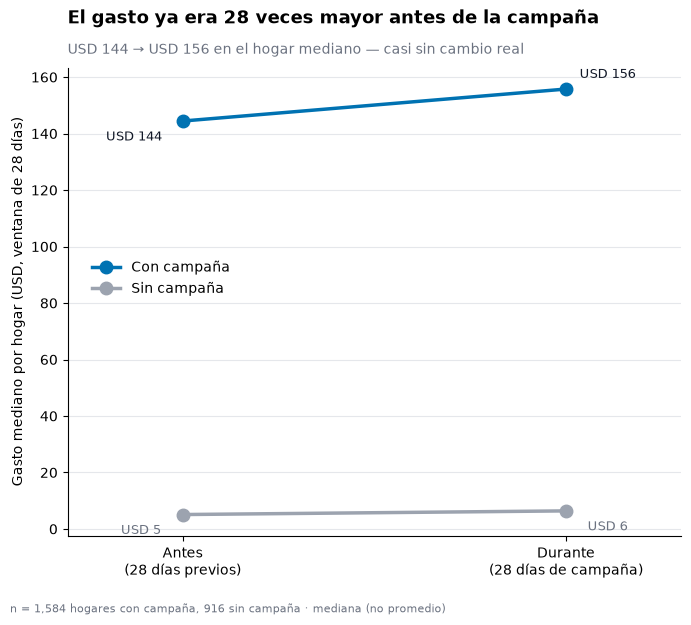

In [37]:
# =========================================================
# Gráfico Análisis 4 · Slope chart — antes/durante, con vs. sin campaña
# =========================================================

# Usamos la MEDIANA (no el promedio) porque la distribución tiene cola larga
# (hogares de alto gasto) que distorsiona el promedio — mismo criterio del
# Análisis 1. Nota: esta es la diferencia de MEDIANAS POBLACIONALES en cada
# momento, distinta de la mediana del CAMBIO por hogar (+USD 0.14, reportada
# en el texto) — ver aclaración en el párrafo posterior al gráfico.
pre_tratado = gasto_por_hogar_tratados["VENTA_PRE"].median()
durante_tratado = gasto_por_hogar_tratados["VENTA_DURANTE"].median()
pre_control = gasto_por_hogar_control["VENTA_PRE"].median()
durante_control = gasto_por_hogar_control["VENTA_DURANTE"].median()

fig, ax = plt.subplots(figsize=(7, 6))

# Línea del grupo CON campaña
ax.plot([0, 1], [pre_tratado, durante_tratado], marker="o", ms=9,
        color="#0072B2", lw=2.5, zorder=3, label="Con campaña")

# Línea del grupo SIN campaña
ax.plot([0, 1], [pre_control, durante_control], marker="o", ms=9,
        color="#9ca3af", lw=2.5, zorder=3, label="Sin campaña")

# Etiquetas de valor — desplazadas para no chocar con la leyenda
ax.annotate(f"USD {pre_tratado:,.0f}", xy=(0, pre_tratado),
            xytext=(-35, -14), textcoords="offset points",
            ha="center", fontsize=9, color="#111827")
ax.annotate(f"USD {durante_tratado:,.0f}", xy=(1, durante_tratado),
            xytext=(30, 8), textcoords="offset points",
            ha="center", fontsize=9, color="#111827")
ax.annotate(f"USD {pre_control:,.0f}", xy=(0, pre_control),
            xytext=(-30, -14), textcoords="offset points",
            ha="center", fontsize=9, color="#6b7280")
ax.annotate(f"USD {durante_control:,.0f}", xy=(1, durante_control),
            xytext=(30, -14), textcoords="offset points",
            ha="center", fontsize=9, color="#6b7280")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Antes\n(28 días previos)", "Durante\n(28 días de campaña)"])
ax.set_xlim(-0.3, 1.3)
ax.set_ylabel("Gasto mediano por hogar (USD, ventana de 28 días)")

ax.set_title(
    "El gasto ya era 28 veces mayor antes de la campaña",
    fontsize=13, pad=32, loc="left", fontweight="bold",
)
ax.text(
    0, 1.03, "USD 144 → USD 156 en el hogar mediano — casi sin cambio real",
    transform=ax.transAxes, fontsize=10, color="#6b7280",
)

ax.legend(loc="center left", frameon=False, bbox_to_anchor=(0.02, 0.55))
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.grid(axis="y", color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)

fig.text(
    0.02, -0.03,
    f"n = {len(gasto_por_hogar_tratados):,} hogares con campaña, "
    f"{len(gasto_por_hogar_control):,} sin campaña · mediana (no promedio)",
    fontsize=8, color="#6b7280",
)

plt.tight_layout()

os.makedirs("figuras", exist_ok=True)
fig.savefig("figuras/g4_slope_campanas.png", dpi=200, bbox_inches="tight")
plt.show()

### Análisis 4 — Efectividad de campañas y sesgo de targeting

**1. Existe una asimetría estructural previa a cualquier contacto publicitario.** El
hogar mediano seleccionado para recibir campañas registraba un gasto basal de
USD 144.44 en 28 días, frente a USD 5.10 en el grupo no contactado (una disparidad
de 28x), evidenciando que el criterio de targeting prioriza a clientes de alto valor
preexistente, no hogares elegidos al azar.

**2. Controlando por el histórico individual del propio hogar, el estímulo arrojó una
variación mediana de apenas +USD 0.14** (media: +USD 5.04) durante la ventana de
28 días de la campaña, frente a una variación de -USD 2.06 en el grupo sin campaña
en el mismo período. Esto confirma que las campañas actúan como un mecanismo de
retención y fidelización de cartera, no como un detonador de volumen incremental.

**3. Implicación estratégica (Palanca C):** desaconseja asumir que expandir las
campañas generará ventas incrementales. Si en el segmento de mayor valor la
redención fue de solo 27.4% y el lift mediano de apenas +USD 0.14, no hay evidencia
en los datos para proyectar una mejor respuesta en hogares de bajo gasto (USD 5.10).
Cualquier decisión de cobertura requeriría un piloto controlado previo, asignando
campaña aleatoriamente a una muestra de hogares de bajo gasto — algo que no ha
ocurrido en este dataset.

*(Ver celdas de código del Análisis 4)*

**¿Qué fracción de los hogares tiene datos demográficos, y en qué se parecen — o no —
al resto en su comportamiento de compra?**

=== COMPARACIÓN DE GASTO: CON VS. SIN DEMOGRAFÍA ===
Hogares con demografía: 801
Hogares sin demografía: 1,699

-- CON demografía --
  Mediana: US$ 4,676
  IQR (P25-P75): US$ 2,970 - US$ 7,165
  Media (referencia): US$ 5,615

-- SIN demografía --
  Mediana: US$ 1,397
  IQR (P25-P75): US$ 647 - US$ 2,568
  Media (referencia): US$ 2,095

Diferencia de mediana: +234.8%


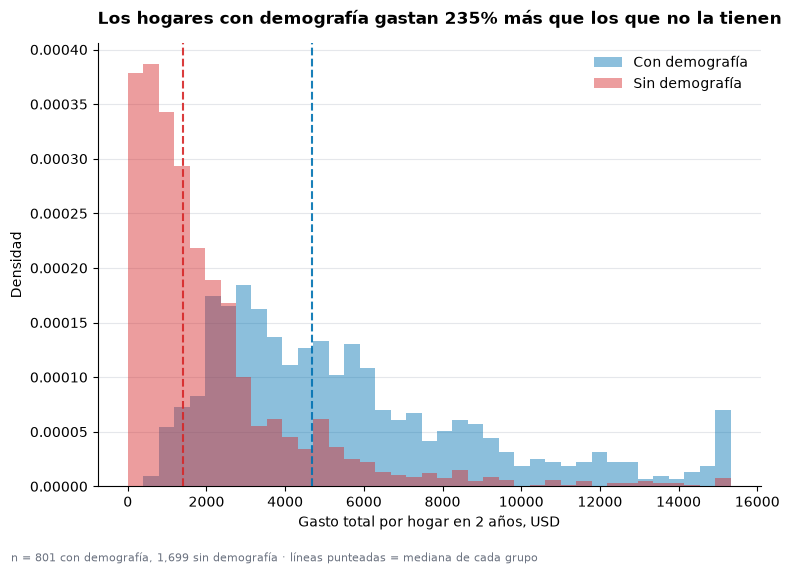

In [38]:
# =========================================================
# Análisis 5 · Cobertura demográfica: ¿los hogares con y sin
# demografía se parecen en su comportamiento de compra?
# =========================================================

# 1. Identificar los dos grupos usando gasto_hh_total (ya calculado en el Análisis 1)
hogares_con_demo_ids = set(hh_demographic["household_key"].unique())

gasto_con_demo = gasto_hh_total[gasto_hh_total.index.isin(hogares_con_demo_ids)]
gasto_sin_demo = gasto_hh_total[~gasto_hh_total.index.isin(hogares_con_demo_ids)]

print("=== COMPARACIÓN DE GASTO: CON VS. SIN DEMOGRAFÍA ===")
print(f"Hogares con demografía: {len(gasto_con_demo):,}")
print(f"Hogares sin demografía: {len(gasto_sin_demo):,}")

for nombre, serie in [("CON demografía", gasto_con_demo), ("SIN demografía", gasto_sin_demo)]:
    print(f"\n-- {nombre} --")
    print(f"  Mediana: US$ {serie.median():,.0f}")
    print(f"  IQR (P25-P75): US$ {serie.quantile(0.25):,.0f} - US$ {serie.quantile(0.75):,.0f}")
    print(f"  Media (referencia): US$ {serie.mean():,.0f}")

diferencia_mediana = (gasto_con_demo.median() / gasto_sin_demo.median() - 1) * 100
print(f"\nDiferencia de mediana: {diferencia_mediana:+.1f}%")

# 2. Gráfico — histogramas de densidad superpuestos (sin dependencias externas)
fig, ax = plt.subplots(figsize=(8, 5.5))

tope_visual = gasto_hh_total.quantile(0.99)  # recortar cola extrema, mismo criterio que antes
bins = np.linspace(0, tope_visual, 40)

for nombre, serie, color in [
    ("Con demografía", gasto_con_demo, "#0072B2"),
    ("Sin demografía", gasto_sin_demo, "#d62728"),
]:
    ax.hist(
        serie.clip(upper=tope_visual), bins=bins, density=True,
        alpha=0.45, color=color, label=nombre, zorder=3,
    )
    ax.axvline(serie.median(), color=color, ls="--", lw=1.5, alpha=0.9, zorder=4)

ax.set_xlabel("Gasto total por hogar en 2 años, USD")
ax.set_ylabel("Densidad")
ax.set_title(
    "Los hogares con demografía gastan 235% más que los que no la tienen",
    fontsize=12.5, pad=14, loc="left", fontweight="bold",
)
ax.legend(loc="upper right", frameon=False)
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.grid(axis="y", color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)

fig.text(
    0.02, -0.03,
    f"n = {len(gasto_con_demo):,} con demografía, {len(gasto_sin_demo):,} sin demografía · "
    f"líneas punteadas = mediana de cada grupo",
    fontsize=8, color="#6b7280",
)

plt.tight_layout()
os.makedirs("figuras", exist_ok=True)
fig.savefig("figuras/g5_histograma_demografia.png", dpi=200, bbox_inches="tight")
plt.show()

### Análisis 5 — Cobertura demográfica: un sesgo de autoselección masivo

**Sesgo de autoselección masivo:** los hogares con demografía gastan 3.3 veces más
que los no registrados (mediana de USD 4,676 vs. USD 1,397; +235%), con rangos
intercuartílicos que apenas se traslapan (USD 2,970-7,165 vs. USD 647-2,568).
Quienes entregan sus datos demográficos son, sistemáticamente, los hogares de mayor
gasto — no una muestra aleatoria del cliente promedio.

**No generalizable a la cadena:** cualquier perfil de edad, ingreso o tamaño de hogar
que se construya a partir de `hh_demographic` describe exclusivamente al segmento de
alto gasto que además decidió compartir sus datos (32.04% de la base). Extrapolar
ese perfil al 68% restante distorsionaría cualquier decisión, pues ese grupo maneja
volúmenes de compra radicalmente menores y podría tener patrones de comportamiento
distintos que la demografía disponible no puede capturar.

*(Ver celda de código del Análisis 5)*

## Recomendación final — Palanca C (Mecánica)

**Reasignar el descuento de categorías en caída a categorías en crecimiento,
congelando la expansión de campañas.**

Recomendamos reasignar progresivamente el presupuesto de descuento en góndola desde
categorías contractivas hacia categorías en expansión, manteniendo las campañas
directas estrictamente como herramienta de fidelización para clientes de alto valor
sin expandir su cobertura, **porque** el descuento en góndola representa el 96.5% del
esfuerzo promocional pero se concentra en líneas que pierden participación relativa
(r = -0.383), mientras que las campañas directas exhiben un lift incremental mediano
casi nulo (+USD 0.14) con una fricción del 72.6% sin redención en su propio segmento
core, **y esperamos** someter a optimización y reasignación una masa crítica de hasta
USD 286,822 en descuentos actualmente atrapados en 8 categorías de bajo desempeño
(aproximadamente una quinta parte del gasto promocional total). **El riesgo principal
es** la aceleración en la pérdida de volumen por causalidad inversa (que el descuento
estuviera frenando una caída aún mayor en categorías sensibles al precio), lo cual
exige implementar la reasignación mediante pruebas piloto controladas (test & learn)
a nivel de tienda antes de retirar el estímulo de forma masiva.

### Por qué no las otras dos palancas

- **Palanca A (Hogares):** existe una minoría real que concentra gasto (454 hogares,
  18.2% explican la mitad del gasto), pero cualquier segmentación por edad o ingreso
  usando `hh_demographic` está contaminada por un sesgo de autoselección de 235% en
  gasto — no es seguro generalizar un perfil demográfico al 68% de hogares sin esos
  datos.
- **Palanca B (Categorías):** el análisis de mix identificó ganadores y perdedores de
  participación con rigor (agua, snacks vs. refrescos, masas), pero no arroja una
  acción de inversión tan clara y accionable como la mecánica de descuento —
  funciona mejor como insumo *dentro* de la Palanca C (qué categorías priorizar al
  reasignar) que como palanca independiente.

## Lo que no pudimos responder

**1. Dirección de la causalidad entre descuento y participación.** La correlación
negativa (r = -0.383) es consistente tanto con "el descuento causa la caída" como con
"la caída causa el descuento" (respuesta defensiva). Con datos observacionales, sin
variación exógena en precios, ambas explicaciones son indistinguibles.
*Necesitaríamos:* un experimento controlado (A/B test de nivel de descuento por
tienda o región) para aislar el efecto causal.

**2. Si las campañas funcionarían en hogares de bajo gasto.** El lift medido
(+USD 0.14) proviene exclusivamente de hogares que ya eran 28 veces más valiosos
antes de recibir campaña — nunca se ha probado el estímulo en el segmento de bajo
gasto. *Necesitaríamos:* un piloto con asignación aleatoria de campaña en hogares de
bajo gasto histórico.

**3. El rol del display y el mailer en tienda.** No se utilizó `causal_data.csv`
(36M de filas, no obligatoria para los 5 análisis) por su tamaño y por estar fuera
del alcance definido. No sabemos si la exhibición física en tienda explica parte de
por qué ciertas categorías descontadas no logran crecer. *Necesitaríamos:* cruzar
`causal_data.csv` contra las categorías identificadas en el Análisis 2×3.

**4. Estacionalidad real del negocio.** El dataset solo provee `DAY` (1-711) y
`WEEK_NO` (1-102), sin año ni mes calendario, por anonimización. No podemos separar
tendencia genuina de estacionalidad (por ejemplo, si semanas de alto gasto coinciden
con fiestas reales). *Necesitaríamos:* el mapeo de `DAY` a fecha calendario real,
que dunnhumby no provee en este dataset.